In [1]:
# Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [2]:
# find -L /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/align_dna/GRCh37 -name "*.bam" -exec realpath {} + > /mnt/NAS3/home/jiwon/ECTRES/data/bam_list_all_origin.txt

In [2]:
# bam_manifest.to_csv('../manifest/ECTRES_clones_nf_dna_bam.csv',index=False)  ## 20260309
# bam_manifest.to_csv('/mnt/NAS3/home/jiwon/ECTRES/manifest/ECTRES_clones_nf_dna_bam.csv',index=False)  ## 20260309
bam_manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_bam.csv')  ## 20260309


In [3]:
root_path = '/mnt/NAS3/home/jiwon/ECTRES/summary/ichorCNA/1MB'

file = glob.glob(f'{root_path}/*params*.csv')[0]
df_ichor = pd.read_csv(file)

In [4]:
ichor_df= pd.merge(df_ichor, bam_manifest[['aliquot_barcode','source_barcode','sample_id']], on='aliquot_barcode', how='left')

ichor_df.shape

(77, 17)

In [5]:
# ichor_df.to_csv('../summary/ichorCNA_summary_origin.csv', index=False)
# ichor_df.to_csv('../summary/ichorCNA_summary_tumor_only.csv', index=False)
# ichor_df=pd.read_csv('../summary/ichorCNA_summary_tumor_only.csv')
ichor_df.shape #(77, 17)
ichor_df.head(2)

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id
0,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,female,1,2.732,NaN,0,0,NaN,0.000043,-0.1423,"-1, -0.31, 0.094, 0.38, 0.6, 0.79, 0.94","68, 550, 340, 230, 290, 68, 68",0.030,0.05221,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,H2170,NCI_15
1,ECTRES-H2170-0001-TPX-A22-WGS-KCXAQ5,female,1,2.676,NaN,0,0,NaN,0.000039,-0.5077,"-0.98, -0.29, 0.11, 0.4, 0.63, 0.81, 0.96","65, 450, 450, 380, 300, 65, 65",0.031,0.05980,ECTRES-H2170-0001-TPX-A22-WGS-KCXAQ5,H2170,NCI_22


In [7]:
aaSuite_gemline_ms = ichor_df.copy()
aaSuite_gemline_ms['old_source_barcode'] = aaSuite_gemline_ms['source_barcode']
aaSuite_gemline_ms['old_sample_id'] = aaSuite_gemline_ms['sample_id']

# 2. 첫 번째 케이스: ECGI1 + EG_21 조합인 경우만 H2170 + NCI_40으로 변경
cond1 = (aaSuite_gemline_ms['old_source_barcode'] == 'ECGI1') & (aaSuite_gemline_ms['old_sample_id'] == 'EG_21')
aaSuite_gemline_ms.loc[cond1, 'source_barcode'] = 'H2170'
aaSuite_gemline_ms.loc[cond1, 'sample_id'] = 'NCI_X01'

# 3. 두 번째 케이스: H2170 + NCI_10 조합인 경우만 ECGI1 + EG_40으로 변경
cond2 = (aaSuite_gemline_ms['old_source_barcode'] == 'H2170') & (aaSuite_gemline_ms['old_sample_id'] == 'NCI_10')
aaSuite_gemline_ms.loc[cond2, 'source_barcode'] = 'ECGI1'
aaSuite_gemline_ms.loc[cond2, 'sample_id'] = 'EG_X01'

ichor_df = aaSuite_gemline_ms.copy()
# ichor_df.to_csv(f'{root_path}/ichorCNA_summary_params_20260416.csv', index=False)



In [8]:
ichor_df.head(2)

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id,old_source_barcode,old_sample_id
0,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,female,1,2.732,NaN,0,0,NaN,0.000043,-0.1423,"-1, -0.31, 0.094, 0.38, 0.6, 0.79, 0.94","68, 550, 340, 230, 290, 68, 68",0.030,0.05221,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,H2170,NCI_15,H2170,NCI_15
1,ECTRES-H2170-0001-TPX-A22-WGS-KCXAQ5,female,1,2.676,NaN,0,0,NaN,0.000039,-0.5077,"-0.98, -0.29, 0.11, 0.4, 0.63, 0.81, 0.96","65, 450, 450, 380, 300, 65, 65",0.031,0.05980,ECTRES-H2170-0001-TPX-A22-WGS-KCXAQ5,H2170,NCI_22,H2170,NCI_22


In [9]:
ichor_df.columns

Index(['Sample', 'Gender', 'Tumor Fraction', 'Ploidy', 'Subclone Fraction',
       'Fraction Genome Subclonal', 'Fraction CNA Subclonal', 'Coverage',
       'ChrY coverage fraction', 'ChrX median log ratio', 'Student's t mean',
       'Student's t precision', 'Gamma Rate Init', 'GC-Map correction MAD',
       'aliquot_barcode', 'source_barcode', 'sample_id', 'old_source_barcode',
       'old_sample_id'],
      dtype='object')

In [10]:
ichor_df['GC-Map correction MAD'].max()
# ichor_df['Fraction CNA Subclonal'].max()
# ichor_df['Coverage'].max()

0.09224

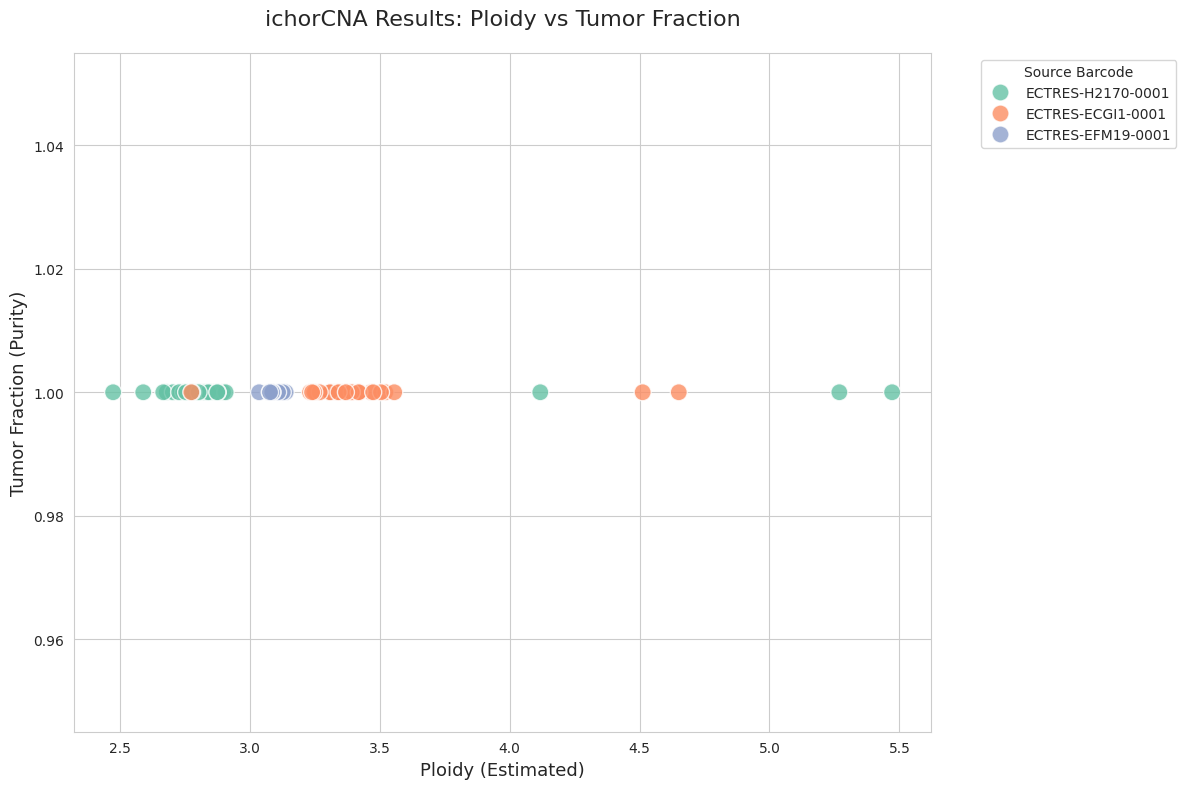

In [11]:
df_ichor=ichor_df.copy()
# 1. 데이터 타입 변환 (숫자형으로 확정)
df_ichor['Ploidy'] = pd.to_numeric(df_ichor['Ploidy'], errors='coerce')
df_ichor['Tumor Fraction'] = pd.to_numeric(df_ichor['Tumor Fraction'], errors='coerce')

# 2. source_barcode 추출 (예: ECTRES-ECGI1-0001-TPX... -> ECTRES-ECGI1-0001)
# 샘플 이름의 구조에 따라 하이픈(-) 기준 앞 3 덩어리를 합칩니다.
df_ichor['source_barcode'] = df_ichor['Sample'].apply(lambda x: "-".join(x.split("-")[:3]))

# 3. 그래프 그리기
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 산점도 생성
scatter = sns.scatterplot(
    data=df_ichor, 
    x='Ploidy', 
    y='Tumor Fraction', 
    hue='source_barcode', 
    palette='Set2',      # 색상 테마 (샘플이 아주 많으면 'husl'이나 'tab20' 추천)
    s=150,               # 점 크기
    alpha=0.8,           # 투명도
    edgecolor='w'        # 점 테두리 흰색
)

# 4. 그래프 꾸미기
plt.title('ichorCNA Results: Ploidy vs Tumor Fraction', fontsize=16, pad=20)
plt.xlabel('Ploidy (Estimated)', fontsize=13)
plt.ylabel('Tumor Fraction (Purity)', fontsize=13)

# 범례(Legend) 위치 조정 (그래프 밖으로 빼서 가독성 확보)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Source Barcode', fontsize=10)

# 5. 축 범위 자동 조정 및 레이아웃 정리
plt.tight_layout()

# 그래프 저장 (선택 사항)
# plt.savefig('ichorCNA_scatter_plot.png', dpi=300)

plt.show()

In [12]:
df_ichor = ichor_df.copy()

candidate_cols = [
    'Ploidy',
    'Coverage',
    'ChrY coverage fraction',
    'ChrX median log ratio',
    "Student's t mean",
    "Student's t precision",
    'Gamma Rate Init',
    'GC-Map correction MAD'
]

for col in candidate_cols:
    df_ichor[col] = pd.to_numeric(df_ichor[col], errors='coerce')

summary_check = pd.DataFrame({
    'n_non_na': df_ichor[candidate_cols].notna().sum(),
    'n_unique': df_ichor[candidate_cols].nunique(dropna=True),
    'min': df_ichor[candidate_cols].min(),
    'max': df_ichor[candidate_cols].max()
}).sort_values('n_unique', ascending=False)

summary_check

,n_non_na,n_unique,min,max
GC-Map correction MAD,77,77,0.047770,0.092240
ChrY coverage fraction,77,76,0.000036,0.000744
ChrX median log ratio,77,76,-1.780000,0.318800
Ploidy,77,74,2.474000,5.472000
Gamma Rate Init,77,32,0.026000,0.071000
Coverage,0,0,NaN,NaN
Student's t mean,0,0,NaN,NaN
Student's t precision,0,0,NaN,NaN


In [13]:
# nextflow run main.nf -profile singularity   --input /mnt/NAS3/home/jiwon/ECTRES/manifest/ECTRES_clones_nf_dna_bam.csv   --outdir /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/ichorCNA/v2/   --window 500000   -w /mnt/NAS3/home/jiwon/HL-NF//nxf_work/ichor -resume

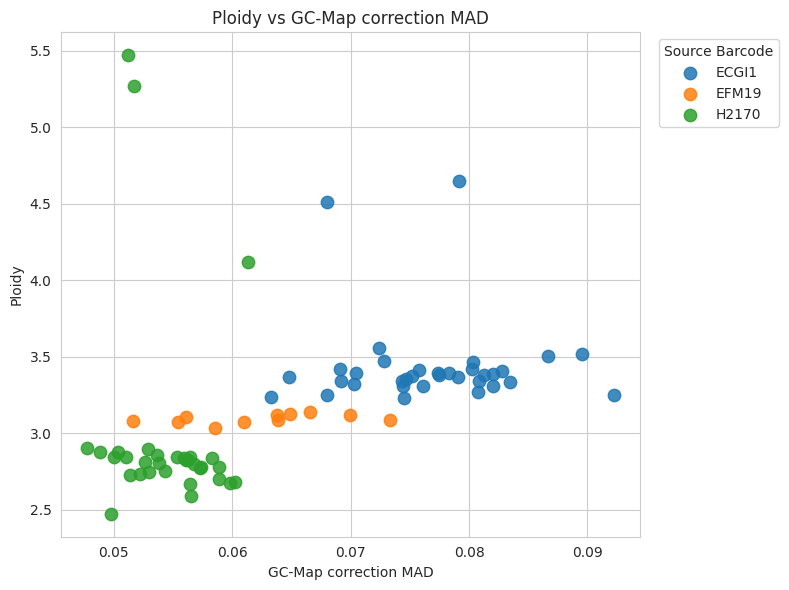

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = ichor_df.copy()

# 1. 문자열 공백 제거 후 숫자형 변환
for col in ['Ploidy', 'GC-Map correction MAD']:
    df_plot[col] = (
        df_plot[col]
        .astype(str)
        .str.strip()
        .replace({'nan': pd.NA, 'NA': pd.NA, '': pd.NA})
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# 2. parental 제외
# df_plot = df_plot[~df_plot['sample_id'].str.contains('parental', case=False, na=False)].copy()

# 3. NA 제거
df_plot = df_plot.dropna(subset=['Ploidy', 'GC-Map correction MAD', 'source_barcode'])

# 4. 그룹별 색 지정
group_order = sorted(df_plot['source_barcode'].dropna().unique())
colors = plt.cm.Set2(range(len(group_order)))
color_map = dict(zip(group_order, colors))

# 5. scatter plot
plt.figure(figsize=(8, 6))

for group in group_order:
    sub = df_plot[df_plot['source_barcode'] == group]
    plt.scatter(
        sub['GC-Map correction MAD'],
        sub['Ploidy'],
        label=group,
        s=80,
        alpha=0.85
    )

plt.xlabel('GC-Map correction MAD')
plt.ylabel('Ploidy')
plt.title('Ploidy vs GC-Map correction MAD')
plt.legend(title='Source Barcode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

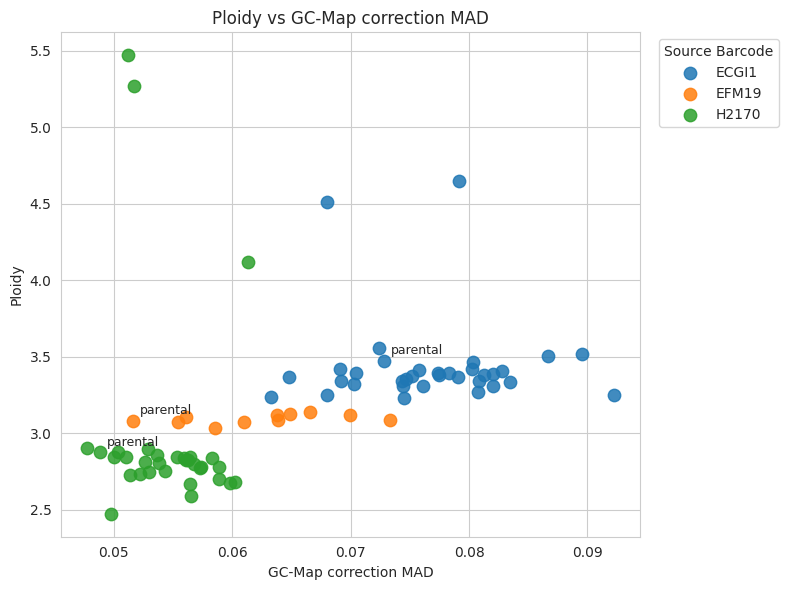

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = ichor_df.copy()

# 1. 문자열 공백 제거 후 숫자형 변환
for col in ['Ploidy', 'GC-Map correction MAD']:
    df_plot[col] = (
        df_plot[col]
        .astype(str)
        .str.strip()
        .replace({'nan': pd.NA, 'NA': pd.NA, '': pd.NA})
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# 2. NA 제거
df_plot = df_plot.dropna(subset=['Ploidy', 'GC-Map correction MAD', 'source_barcode', 'sample_id'])

# 3. 그룹 순서
group_order = sorted(df_plot['source_barcode'].dropna().unique())

# 4. scatter plot
plt.figure(figsize=(8, 6))

for group in group_order:
    sub = df_plot[df_plot['source_barcode'] == group]
    plt.scatter(
        sub['GC-Map correction MAD'],
        sub['Ploidy'],
        label=group,
        s=80,
        alpha=0.85
    )

# 5. parental 샘플만 annotation
parental_df = df_plot[df_plot['sample_id'].str.contains('parental', case=False, na=False)].copy()

for _, row in parental_df.iterrows():
    plt.annotate(
        row['sample_id'],
        (row['GC-Map correction MAD'], row['Ploidy']),
        xytext=(5, 5),          # 점에서 살짝 오른쪽 위
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('GC-Map correction MAD')
plt.ylabel('Ploidy')
plt.title('Ploidy vs GC-Map correction MAD')
plt.legend(title='Source Barcode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

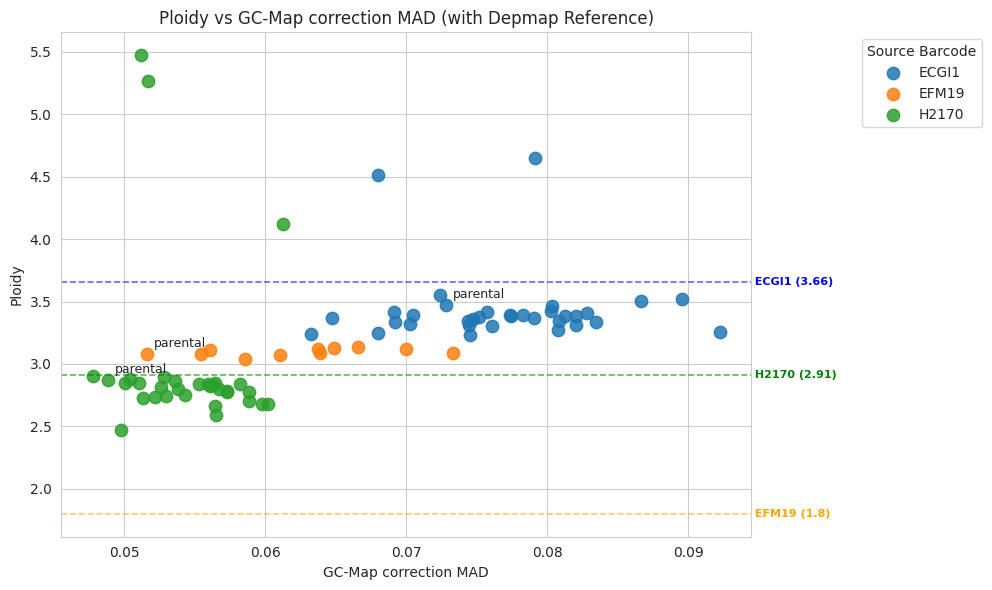

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = ichor_df.copy()

# 1. 문자열 공백 제거 후 숫자형 변환
for col in ['Ploidy', 'GC-Map correction MAD']:
    df_plot[col] = (
        df_plot[col]
        .astype(str)
        .str.strip()
        .replace({'nan': pd.NA, 'NA': pd.NA, '': pd.NA})
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# 2. NA 제거
df_plot = df_plot.dropna(subset=['Ploidy', 'GC-Map correction MAD', 'source_barcode', 'sample_id'])

# 3. 그룹 순서
group_order = sorted(df_plot['source_barcode'].dropna().unique())

# 4. scatter plot
plt.figure(figsize=(10, 6)) # 라벨 공간 확보를 위해 너비를 조금 늘렸습니다.

for group in group_order:
    sub = df_plot[df_plot['source_barcode'] == group]
    plt.scatter(
        sub['GC-Map correction MAD'],
        sub['Ploidy'],
        label=group,
        s=80,
        alpha=0.85
    )

# 5. parental 샘플만 annotation
parental_df = df_plot[df_plot['sample_id'].str.contains('parental', case=False, na=False)].copy()

for _, row in parental_df.iterrows():
    plt.annotate(
        row['sample_id'],
        (row['GC-Map correction MAD'], row['Ploidy']),
        xytext=(5, 5),          # 점에서 살짝 오른쪽 위
        textcoords='offset points',
        fontsize=9
    )

# --- 6. Depmap Ploidy 기준선 추가 (추가된 부분) ---
depmap_ploidy = {
    'ECGI1': 3.66,
    'EFM19': 1.80,
    'H2170': 2.91
}

# 기준선 색상 설정 (원하는 경우 scatter 색상과 맞출 수 있습니다)
line_colors = {'ECGI1': 'blue', 'EFM19': 'orange', 'H2170': 'green'}

for label, value in depmap_ploidy.items():
    # 수평선 긋기
    plt.axhline(y=value, color=line_colors.get(label, 'gray'), linestyle='--', linewidth=1.2, alpha=0.6)
    
    # 선 우측 끝에 텍스트 추가
    plt.text(
        plt.xlim()[1], # x축 끝 지점
        value, 
        f' {label} ({value})', 
        va='center', 
        ha='left', 
        fontsize=8, 
        color=line_colors.get(label, 'black'),
        fontweight='bold'
    )
# ----------------------------------------------

plt.xlabel('GC-Map correction MAD')
plt.ylabel('Ploidy')
plt.title('Ploidy vs GC-Map correction MAD (with Depmap Reference)')

# 범례와 텍스트 라벨이 겹치지 않도록 배치 조정
plt.legend(title='Source Barcode', bbox_to_anchor=(1.15, 1), loc='upper left')
plt.subplots_adjust(right=0.8) # 우측에 텍스트 라벨이 들어갈 공간 확보

plt.tight_layout()
plt.show()

In [16]:
q1 = df_plot['GC-Map correction MAD'].quantile(0.25)
q3 = df_plot['GC-Map correction MAD'].quantile(0.75)
iqr = q3 - q1
cutoff = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Suggested outlier cutoff:", cutoff)

df_plot['MAD_outlier'] = df_plot['GC-Map correction MAD'] > cutoff
df_plot[['sample_id', 'source_barcode', 'GC-Map correction MAD', 'Ploidy', 'MAD_outlier']].sort_values(
    'GC-Map correction MAD', ascending=False
).head(15)

Q1: 0.05593
Q3: 0.07516
IQR: 0.019230000000000004
Suggested outlier cutoff: 0.10400500000000001


,sample_id,source_barcode,GC-Map correction MAD,Ploidy,MAD_outlier
40,EG_3,ECGI1,0.09224,3.253,False
58,EG_18,ECGI1,0.08952,3.522,False
63,EG_6,ECGI1,0.08663,3.505,False
49,EG_11,ECGI1,0.08348,3.338,False
44,EG_2,ECGI1,0.08278,3.409,False
54,EG_26,ECGI1,0.08206,3.309,False
41,EG_27,ECGI1,0.08205,3.386,False
51,EG_8,ECGI1,0.08125,3.382,False
36,EG_4,ECGI1,0.08083,3.341,False
56,EG_25,ECGI1,0.08072,3.269,False


In [19]:
df_plot.head(2)
df_plot[(df_plot['source_barcode']=='ECGI1')&(df_plot['Ploidy']>4)]

# ichor_df[(ichor_df['sample_id']=='parental')&(ichor_df['source_barcode']=='EFM19')]

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id,old_source_barcode,old_sample_id
35,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,female,1,4.651,NaN,0,0,NaN,0.000670,-0.8182,"-1.5, -0.84, -0.44, -0.15, 0.072, 0.25, 0.41","48, 23, 96, 170, 150, 200, 32",0.041,0.07915,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,ECGI1,EG_5,ECGI1,EG_5
62,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,female,1,4.512,NaN,0,0,NaN,0.000362,-0.8163,"-1.5, -0.81, -0.41, -0.12, 0.1, 0.28, 0.44","52, 20, 66, 270, 160, 290, 24",0.038,0.06800,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,EG_1,ECGI1,EG_1


## ECTRES_ichorCNA_correctedDepth_20260319.csv

In [18]:
# file = glob.glob(f'{root_path}/*correctedDepth*.csv')[0]
# df_ichor = pd.read_csv(file)

correctedDepth = pd.read_csv(glob.glob(f'{root_path}/*correctedDepth*.csv')[0])

 
correctedDepth= pd.merge(correctedDepth, bam_manifest[['aliquot_barcode','source_barcode','sample_id']], on='aliquot_barcode', how='left')


print(correctedDepth.shape)

correctedDepth.head(2)

(199738, 7)


,aliquot_barcode,chr,start,end,log2_TNratio_corrected,source_barcode,sample_id
0,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,1,1000001,2000000,NaN,H2170,NCI_15
1,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,1,2000001,3000000,NaN,H2170,NCI_15


In [19]:
correctedDepth[correctedDepth['sample_id']=='parental']

,aliquot_barcode,chr,start,end,log2_TNratio_corrected,source_barcode,sample_id
80414,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,1,1000001,2000000,NaN,H2170,parental
80415,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,1,2000001,3000000,NaN,H2170,parental
80416,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,1,4000001,5000000,-0.614174,H2170,parental
80417,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,1,5000001,6000000,-0.615594,H2170,parental
80418,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,1,6000001,7000000,-0.538942,H2170,parental
...,...,...,...,...,...,...,...
199733,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,145000001,146000000,0.294091,EFM19,parental
199734,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,146000001,147000000,0.349225,EFM19,parental
199735,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,147000001,148000000,0.233060,EFM19,parental
199736,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,149000001,150000000,NaN,EFM19,parental


<Figure size 1000x800 with 0 Axes>

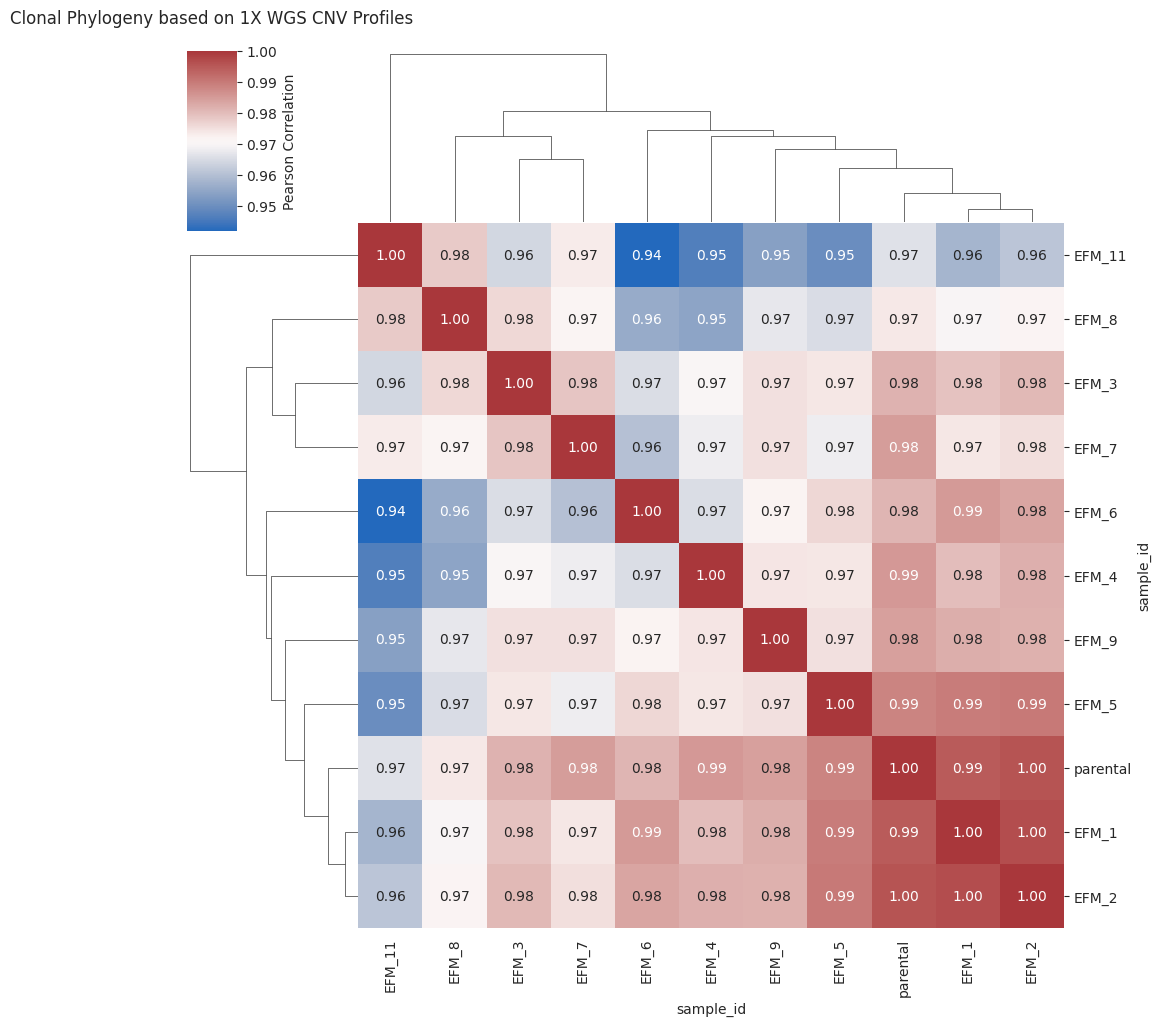

In [20]:
# df = correctedDepth[(correctedDepth['source_barcode']=='EFM19')&(correctedDepth['sample_id']!='parental')]
df = correctedDepth[(correctedDepth['source_barcode']=='EFM19')]

df_wide = df.pivot_table(
    index=['chr', 'start', 'end'], 
    columns='sample_id', 
    values='log2_TNratio_corrected'
).dropna()

# 3. 샘플 간 상관계수(Correlation) 행렬 계산
corr_matrix = df_wide.corr()

# 4. Clustermap 시각화 (계통수 확인)
plt.figure(figsize=(10, 8))
sns.clustermap(corr_matrix, cmap='vlag', annot=True, fmt=".2f",
               cbar_kws={'label': 'Pearson Correlation'})
plt.title('Clonal Phylogeny based on 1X WGS CNV Profiles', pad=20)
plt.show()

In [21]:
# df_wide.shape

[*] Linearizing genomic coordinates...
[*] Generating Genome-wide CNV Plot...


<ipython-input-22-45bc43b0581e>:97: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in leg.legendHandles:


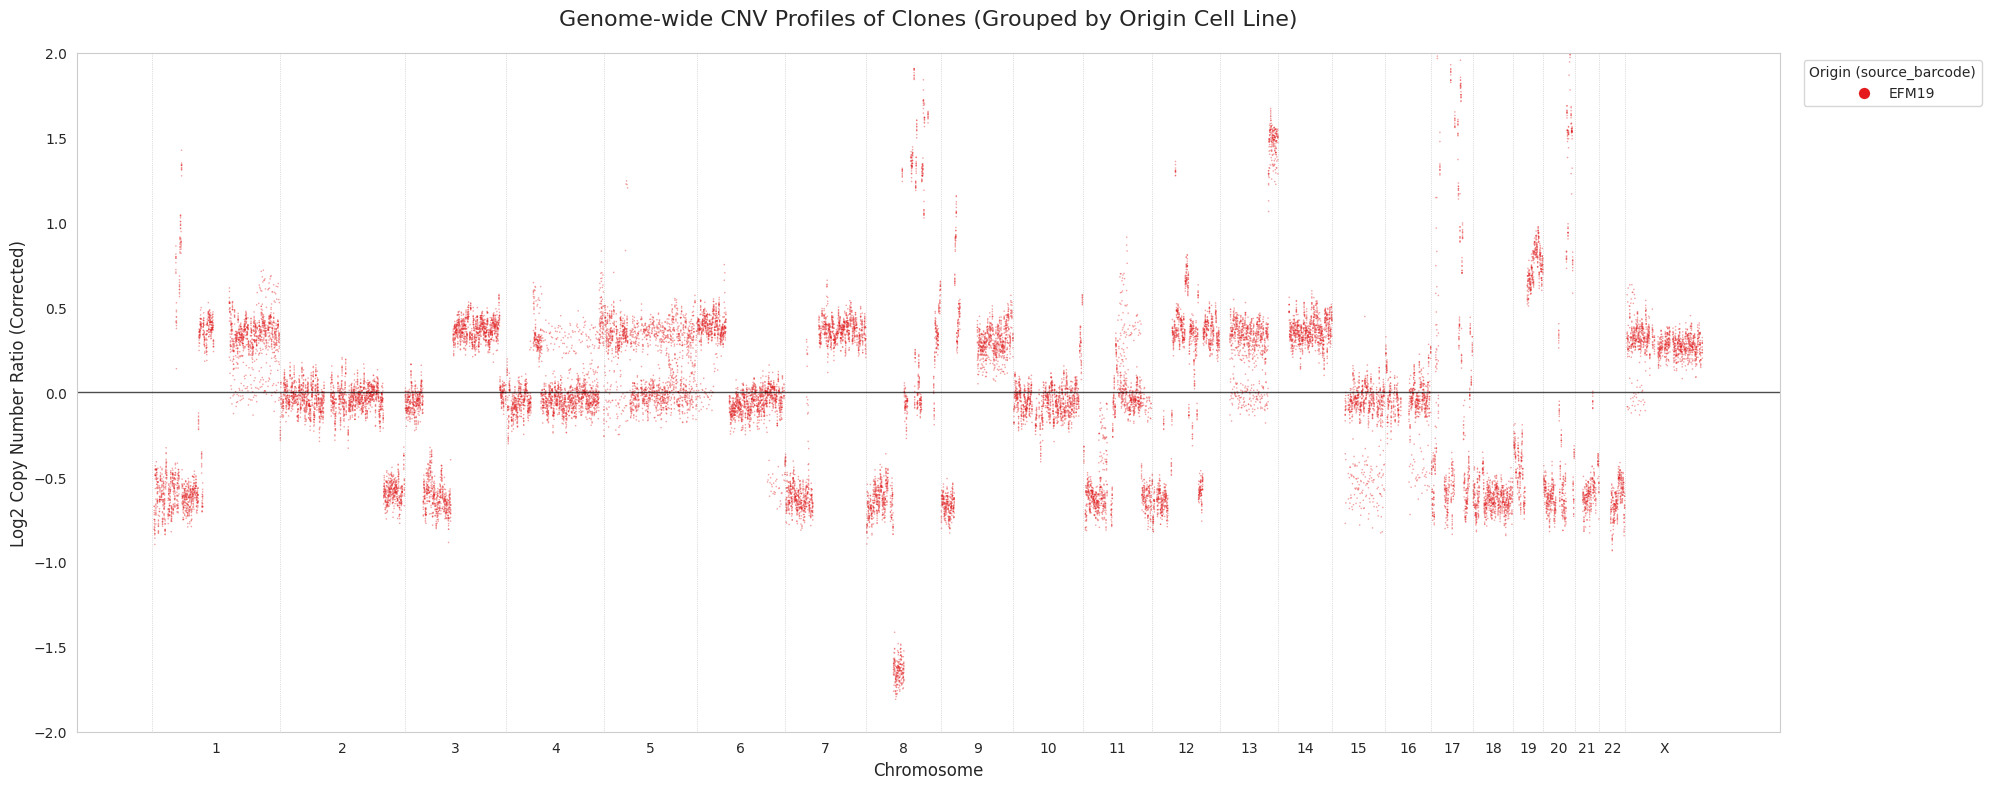

[*] Process completed.


In [22]:
# 3. 데이터 필터링: sample_id가 'parental'인 것 제외
df_plot = df[df['sample_id'] != 'parental'].copy()
df_plot = df.copy()

# 4. NA 값 제거 (시각화 오류 방지)
df_plot = df_plot.dropna(subset=['log2_TNratio_corrected'])


print("[*] Linearizing genomic coordinates...")

# 염색체 순서 정의 (숫자 -> 문자 순 정렬 방지)
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
# 데이터 내 염색체 컬럼을 Categorical 타입으로 변환하여 순서 고정
df_plot['chr'] = pd.Categorical(df_plot['chr'].astype(str), categories=chrom_order, ordered=True)
df_plot = df_plot.sort_values(['chr', 'start'])

# 각 염색체의 누적 길이를 계산하여 오프셋(Offset) 생성
cumulative_pos = 0
chrom_offsets = {}
ticks = []
labels = []

# 각 염색체별로 오프셋 계산 및 X축 라벨 위치 잡기
for chrom in chrom_order:
    # 해당 염색체 데이터만 추출
    subset = df_plot[df_plot['chr'] == chrom]
    if subset.empty: continue
    
    # 이 염색체의 시작점(오프셋) 저장
    chrom_offsets[chrom] = cumulative_pos
    
    # 이 염색체의 최대 길이 확인 (대략적인 추정)
    chrom_max = subset['end'].max()
    
    # 라벨 위치: 현재 누적 길이 + 염색체 중간 지점
    ticks.append(cumulative_pos + chrom_max / 2)
    labels.append(chrom)
    
    # 누적 길이 업데이트
    cumulative_pos += chrom_max

# 오프셋을 적용하여 새로운 게놈 좌표(genome_pos) 컬럼 생성
df_plot['genome_pos'] = df_plot.apply(
    lambda row: row['start'] + chrom_offsets[str(row['chr'])], axis=1
)

# ==========================================
# [3] 시각화 (Genome-wide Scatter Plot)
# ==========================================
print("[*] Generating Genome-wide CNV Plot...")

# 그래프 크기 설정 (게놈 전체를 봐야 하므로 가로로 길게)
plt.figure(figsize=(20, 8))

# Scatter Plot 그리기
# s=1: 점의 크기를 아주 작게 하여 노이즈를 줄임
# alpha=0.5: 점들을 투명하게 하여 겹치는 영역의 밀도를 표현
scatter = sns.scatterplot(
    data=df_plot, 
    x='genome_pos', 
    y='log2_TNratio_corrected', 
    hue='source_barcode',  # 기원 세포주별로 색상 지정
    palette='Set1',        # 겹치지 않는 뚜렷한 색상 팔레트
    s=1, 
    alpha=0.4,
    edgecolor=None        # 점 테두리 제거 (가독성 증가)
)

# -- 그래프 서식 설정 --

# y=0 (정상 복제수) 기준선 그리기
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)

# 염색체 경계선 그리기 (회색 점선)
for pos in chrom_offsets.values():
    plt.axvline(pos, color='grey', linestyle=':', linewidth=0.5, alpha=0.5)

# X축 설정: 염색체 라벨 표시
plt.xticks(ticks, labels, fontsize=10)
plt.xlabel('Chromosome', fontsize=12)

# Y축 설정: Log2 Ratio 범위 (ichorCNA 통상 범위로 제한)
plt.ylim(-2, 2) 
plt.ylabel('Log2 Copy Number Ratio (Corrected)', fontsize=12)

plt.title('Genome-wide CNV Profiles of Clones (Grouped by Origin Cell Line)', fontsize=16, pad=20)

# 범례 설정 (점 크기가 1이라 범례가 안 보이므로 수동으로 마커 크기 키움)
leg = plt.legend(
    title='Origin (source_barcode)', 
    bbox_to_anchor=(1.01, 1), 
    loc='upper left',
    markerscale=15  # 본 그래프의 점 크기(s=1)에 비례해서 범례 점 크기를 15배로 키움
)

# 투명도(alpha)만 1.0으로 뚜렷하게 복구
for handle in leg.legendHandles:
    handle.set_alpha(1.0) 
    
    # 혹시 markerscale로 충분히 안 커졌다면 아래 코드가 안전하게 크기를 키워줍니다.
    if hasattr(handle, 'set_markersize'):
        handle.set_markersize(8)

plt.grid(False) # 격자 제거
plt.tight_layout()
plt.show()

print("[*] Process completed.")

In [24]:


cna_seg = pd.read_csv(glob.glob(f'{root_path}/*cna_seg*.csv')[0])
cna_seg.rename(columns = {'sample_id' : 'aliquot_barcode'}, inplace = True)
# seg = pd.read_csv('../summary/ichorCNA/ECTRES_ichorCNA_seg_20260319.csv')

cna_seg= pd.merge(cna_seg, bam_manifest[['aliquot_barcode','source_barcode','sample_id']], on='aliquot_barcode', how='left')


aaSuite_gemline_ms = cna_seg.copy()
aaSuite_gemline_ms['old_source_barcode'] = aaSuite_gemline_ms['source_barcode']
aaSuite_gemline_ms['old_sample_id'] = aaSuite_gemline_ms['sample_id']

# 2. 첫 번째 케이스: ECGI1 + EG_21 조합인 경우만 H2170 + NCI_40으로 변경
cond1 = (aaSuite_gemline_ms['old_source_barcode'] == 'ECGI1') & (aaSuite_gemline_ms['old_sample_id'] == 'EG_21')
aaSuite_gemline_ms.loc[cond1, 'source_barcode'] = 'H2170'
aaSuite_gemline_ms.loc[cond1, 'sample_id'] = 'NCI_40'

# 3. 두 번째 케이스: H2170 + NCI_10 조합인 경우만 ECGI1 + EG_40으로 변경
cond2 = (aaSuite_gemline_ms['old_source_barcode'] == 'H2170') & (aaSuite_gemline_ms['old_sample_id'] == 'NCI_10')
aaSuite_gemline_ms.loc[cond2, 'source_barcode'] = 'ECGI1'
aaSuite_gemline_ms.loc[cond2, 'sample_id'] = 'EG_40'

cna_seg = aaSuite_gemline_ms.copy()



print(cna_seg.shape)




(199738, 15)


In [25]:
cna_seg.head()

df = cna_seg.copy()

import numpy as np

conditions = [
    # 1. ecDNA 특화 기준: 예를 들어 카피 수 10 이상 (연구에 맞게 15나 20으로 조절 가능)
    (df['Corrected_Copy_Number'] >= 15),  
    # 2. 공식 HLAMP: 5 카피 이상 ~ 초고도 증폭 미만
    (df['Corrected_Copy_Number'] >= 4.5) & (df['Corrected_Copy_Number'] < 15), 
    # 3. 공식 AMPL: 4 copies (3.5 ~ 4.5 미만)
    (df['Corrected_Copy_Number'] >= 3.5) & (df['Corrected_Copy_Number'] < 4.5),  
    # 4. 공식 GAIN: 3 copies (2.5 ~ 3.5 미만)
    (df['Corrected_Copy_Number'] >= 2.5) & (df['Corrected_Copy_Number'] < 3.5),  
    # 5. 공식 NEUT: 2 copies (1.5 ~ 2.5 미만) - 정상
    (df['Corrected_Copy_Number'] >= 1.5) & (df['Corrected_Copy_Number'] < 2.5), 
    # 6. 공식 HETD: 1 copy (0.5 ~ 1.5 미만) - 이형접합 결실
    (df['Corrected_Copy_Number'] > 0.5) & (df['Corrected_Copy_Number'] < 1.5),  
    # 7. 공식 HOMD: 0 copy (0.5 이하) - 동형접합 결실
    (df['Corrected_Copy_Number'] <= 0.5)                                      
]

# 부여할 새로운 이름표
choices = ['Ultra_HLAMP', 'HLAMP', 'AMP', 'GAIN', 'NEUT', 'HETD', 'HOMD']

# 기존 event를 대체할 완벽한 새 컬럼 생성
df['Reassigned_Event'] = np.select(conditions, choices, default='Unknown')


cna_seg=df.copy()

# cna_seg.to_csv('../summary/ichorCNA/ECTRES_ichorCNA_cna_seg_20260331.csv',index=False)


In [26]:

df_gtf = pd.read_csv('../data/CGC.gtf', sep='\t', comment='#', header=None,
                     names=['chr', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])

df_gtf.head()

# 2. 정규표현식(Regex)으로 알짜배기 정보만 쏙쏙 뽑아내기!
# gene_name과 RolesinCancer를 추출합니다.
df_gtf['gene_name'] = df_gtf['attribute'].str.extract(r'gene_name "([^"]+)"')
df_gtf['role'] = df_gtf['attribute'].str.extract(r'RolesinCancer "([^"]+)"')

# 역할(Role) 정보가 없는 애들은 그냥 'unknown'으로 채워줍니다.
df_gtf['role'] = df_gtf['role'].fillna('unknown')

# 3. 염색체 포맷 통일 ('chr' 떼기)
df_gtf['chr'] = df_gtf['chr'].astype(str).str.replace('chr', '')

# 4. 유전자별로 가장 넓은 테두리(Boundary) 잡기
# (이미 feature가 'gene'이라 한 줄씩이겠지만, 안전장치로 걸어둡니다)
df_oncogene = df_gtf.groupby(['chr', 'gene_name', 'role']).agg({'start': 'min', 'end': 'max'}).reset_index()

df_oncogene.head()

,chr,gene_name,role,start,end
0,1,ABL2,"oncogene, fusion",179068465,179198819
1,1,AKT3,oncogene,243651535,244014381
2,1,ARHGEF10L,TSG,17866193,18024369
3,1,ARID1A,"TSG, fusion",27019727,27108595
4,1,ARNT,"oncogene, TSG, fusion",150782189,150849184


In [27]:
df_clean = cna_seg.copy()


# ---------------------------------------------------------
# 2. 맞춤형 매핑 함수 정의
# ---------------------------------------------------------
def map_cgc_custom(row, df_genes):
    chr_clean = str(row['chr']).replace('chr', '')
    # 유전체 좌표 오버랩 조건: (A_start <= B_end) & (A_end >= B_start)
    mask = (df_genes['chr'] == chr_clean) & \
           (df_genes['start'] <= row['end']) & \
           (df_genes['end'] >= row['start'])
    
    hits = df_genes.loc[mask]
    
    if hits.empty:
        return pd.Series([None, None])
    
    # 컬럼 1: 유전자 이름만 (예: "ERBB2, CDK12")
    gene_only = ", ".join(hits['gene_name'].tolist())
    
    # 컬럼 2: 유전자(역할) 형태 (예: "ERBB2(oncogene), CDK12(unknown)")
    gene_with_role = ", ".join([f"{n}({r})" for n, r in zip(hits['gene_name'], hits['role'])])
    
    return pd.Series([gene_only, gene_with_role])

# ---------------------------------------------------------
# 3. 원본 데이터프레임(df_clean) 특정 행에만 업데이트
# ---------------------------------------------------------
# 새로운 컬럼 2개를 NaN으로 초기화
df_clean['cgc_gene'] = np.nan
df_clean['cgc_gene_role'] = np.nan

# HLAMP와 Ultra_HLAMP 구간만 타깃으로 설정
target_mask = df_clean['Reassigned_Event'].isin(['HLAMP', 'Ultra_HLAMP'])

# 타깃 구간에만 함수 적용 후 값 대입
# .values를 붙여 인덱스 불일치 오류를 방지합니다.
df_clean.loc[target_mask, ['cgc_gene', 'cgc_gene_role']] = df_clean[target_mask].apply(
    lambda row: map_cgc_custom(row, df_oncogene), axis=1
).values

# ---------------------------------------------------------
# 4. 결과 확인
# ---------------------------------------------------------
print("✅ 매핑 완료! 'cgc_gene'와 'cgc_gene_role' 컬럼이 추가되었습니다.")
# 맵핑된 결과가 있는 상위 10개 행만 예시로 확인
display_cols = ['sample_id', 'chr', 'start', 'end', 'Reassigned_Event', 'cgc_gene', 'cgc_gene_role']
print(df_clean[target_mask & df_clean['cgc_gene'].notna()][display_cols].head(10))




✅ 매핑 완료! 'cgc_gene'와 'cgc_gene_role' 컬럼이 추가되었습니다.
     sample_id chr      start        end Reassigned_Event          cgc_gene   
105     NCI_15   1  114000001  115000000            HLAMP            TRIM33  \
106     NCI_15   1  115000001  116000000      Ultra_HLAMP      NRAS, TRIM33   
1218    NCI_15   7  116000001  117000000            HLAMP               MET   
1226    NCI_15   7  124000001  125000000            HLAMP              POT1   
1229    NCI_15   7  127000001  128000000            HLAMP              SND1   
1230    NCI_15   7  128000001  129000000            HLAMP               SMO   
1238    NCI_15   7  137000001  138000000            HLAMP           CREB3L2   
1239    NCI_15   7  138000001  139000000            HLAMP  KIAA1549, TRIM24   
1241    NCI_15   7  140000001  141000000            HLAMP              BRAF   
1242    NCI_15   7  141000001  142000000            HLAMP               TRB   

                                        cgc_gene_role  
105                     

In [49]:
print(cna_seg.shape)
df_clean.shape

# df_clean.to_csv(f'{root_path}/ECTRES_ichorCNA_cna_seg_cgc_20260416.csv',index=False)

cna_seg = df_clean.copy()

(199738, 19)


In [30]:
df_clean[(df_clean['Reassigned_Event']=='Ultra_HLAMP')&(df_clean['cgc_gene'].str.contains(r'\bERBB2\b', na=False))]

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,cgc_gene,cgc_gene_role
2192,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,17,37000001,38000000,3,GAIN,3.7372,0,36.0,HLAMP,36.432346,H2170,NCI_15,H2170,NCI_15,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
4786,ECTRES-H2170-0001-TPX-A22-WGS-KCXAQ5,17,37000001,38000000,3,GAIN,3.6002,0,32.0,HLAMP,32.455474,H2170,NCI_22,H2170,NCI_22,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
7380,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,17,37000001,38000000,3,GAIN,3.4330,0,30.0,HLAMP,30.210895,H2170,NCI_9,H2170,NCI_9,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
9974,ECTRES-H2170-0001-TPX-A13-WGS-1NY223,17,37000001,38000000,3,GAIN,3.5217,0,33.0,HLAMP,32.701382,H2170,NCI_13,H2170,NCI_13,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
12568,ECTRES-H2170-0001-TPX-A02-WGS-9UX155,17,37000001,38000000,3,GAIN,4.1487,0,51.0,HLAMP,51.390685,H2170,NCI_2,H2170,NCI_2,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
15162,ECTRES-H2170-0001-TPX-A17-WGS-JXAF26,17,37000001,38000000,3,GAIN,3.1486,0,25.0,HLAMP,25.208858,H2170,NCI_17,H2170,NCI_17,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
17756,ECTRES-H2170-0001-TPX-A07-WGS-3TC449,17,37000001,38000000,3,GAIN,3.6729,0,36.0,HLAMP,36.489317,H2170,NCI_7,H2170,NCI_7,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
20350,ECTRES-H2170-0001-TPX-A18-WGS-3JF019,17,37000001,38000000,3,GAIN,3.5866,0,34.0,HLAMP,34.131244,H2170,NCI_18,H2170,NCI_18,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
22944,ECTRES-H2170-0001-TPX-A23-WGS-NZH3KA,17,37000001,38000000,6,HLAMP2,3.2869,0,53.0,HLAMP,53.408908,H2170,NCI_23,H2170,NCI_23,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
25538,ECTRES-H2170-0001-TPX-A26-WGS-BZG37J,17,37000001,38000000,3,GAIN,3.8359,0,40.0,HLAMP,40.163430,H2170,NCI_26,H2170,NCI_26,Ultra_HLAMP,"CDK12, ERBB2, IKZF3, LASP1","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."


In [31]:
df_clean[(df_clean['Reassigned_Event']=='Ultra_HLAMP')&(df_clean['cgc_gene'].str.contains(r'\bMYC\b', na=False))]

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,cgc_gene,cgc_gene_role
1375,ECTRES-H2170-0001-TPX-A15-WGS-1CS991,8,128000001,129000000,3,GAIN,6.2905,0,214.0,HLAMP,213.848905,H2170,NCI_15,H2170,NCI_15,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
3969,ECTRES-H2170-0001-TPX-A22-WGS-KCXAQ5,8,128000001,129000000,3,GAIN,6.0907,0,182.0,HLAMP,182.390898,H2170,NCI_22,H2170,NCI_22,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
6563,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,8,128000001,129000000,3,GAIN,5.9011,0,167.0,HLAMP,167.161295,H2170,NCI_9,H2170,NCI_9,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
9157,ECTRES-H2170-0001-TPX-A13-WGS-1NY223,8,128000001,129000000,3,GAIN,6.0043,0,183.0,HLAMP,182.769268,H2170,NCI_13,H2170,NCI_13,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
11751,ECTRES-H2170-0001-TPX-A02-WGS-9UX155,8,128000001,129000000,3,GAIN,6.6890,0,299.0,HLAMP,298.944734,H2170,NCI_2,H2170,NCI_2,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
14345,ECTRES-H2170-0001-TPX-A17-WGS-JXAF26,8,128000001,129000000,3,GAIN,5.5735,0,135.0,HLAMP,135.369496,H2170,NCI_17,H2170,NCI_17,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
16939,ECTRES-H2170-0001-TPX-A07-WGS-3TC449,8,128000001,129000000,3,GAIN,6.1437,0,202.0,HLAMP,202.278930,H2170,NCI_7,H2170,NCI_7,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
19533,ECTRES-H2170-0001-TPX-A18-WGS-3JF019,8,128000001,129000000,3,GAIN,6.0910,0,194.0,HLAMP,193.665221,H2170,NCI_18,H2170,NCI_18,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
22127,ECTRES-H2170-0001-TPX-A23-WGS-NZH3KA,8,128000001,129000000,6,HLAMP2,5.7167,0,288.0,HLAMP,287.777197,H2170,NCI_23,H2170,NCI_23,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"
24721,ECTRES-H2170-0001-TPX-A26-WGS-BZG37J,8,128000001,129000000,3,GAIN,6.3364,0,227.0,HLAMP,227.277422,H2170,NCI_26,H2170,NCI_26,Ultra_HLAMP,MYC,"MYC(oncogene, fusion)"


<Figure size 2500x1000 with 0 Axes>

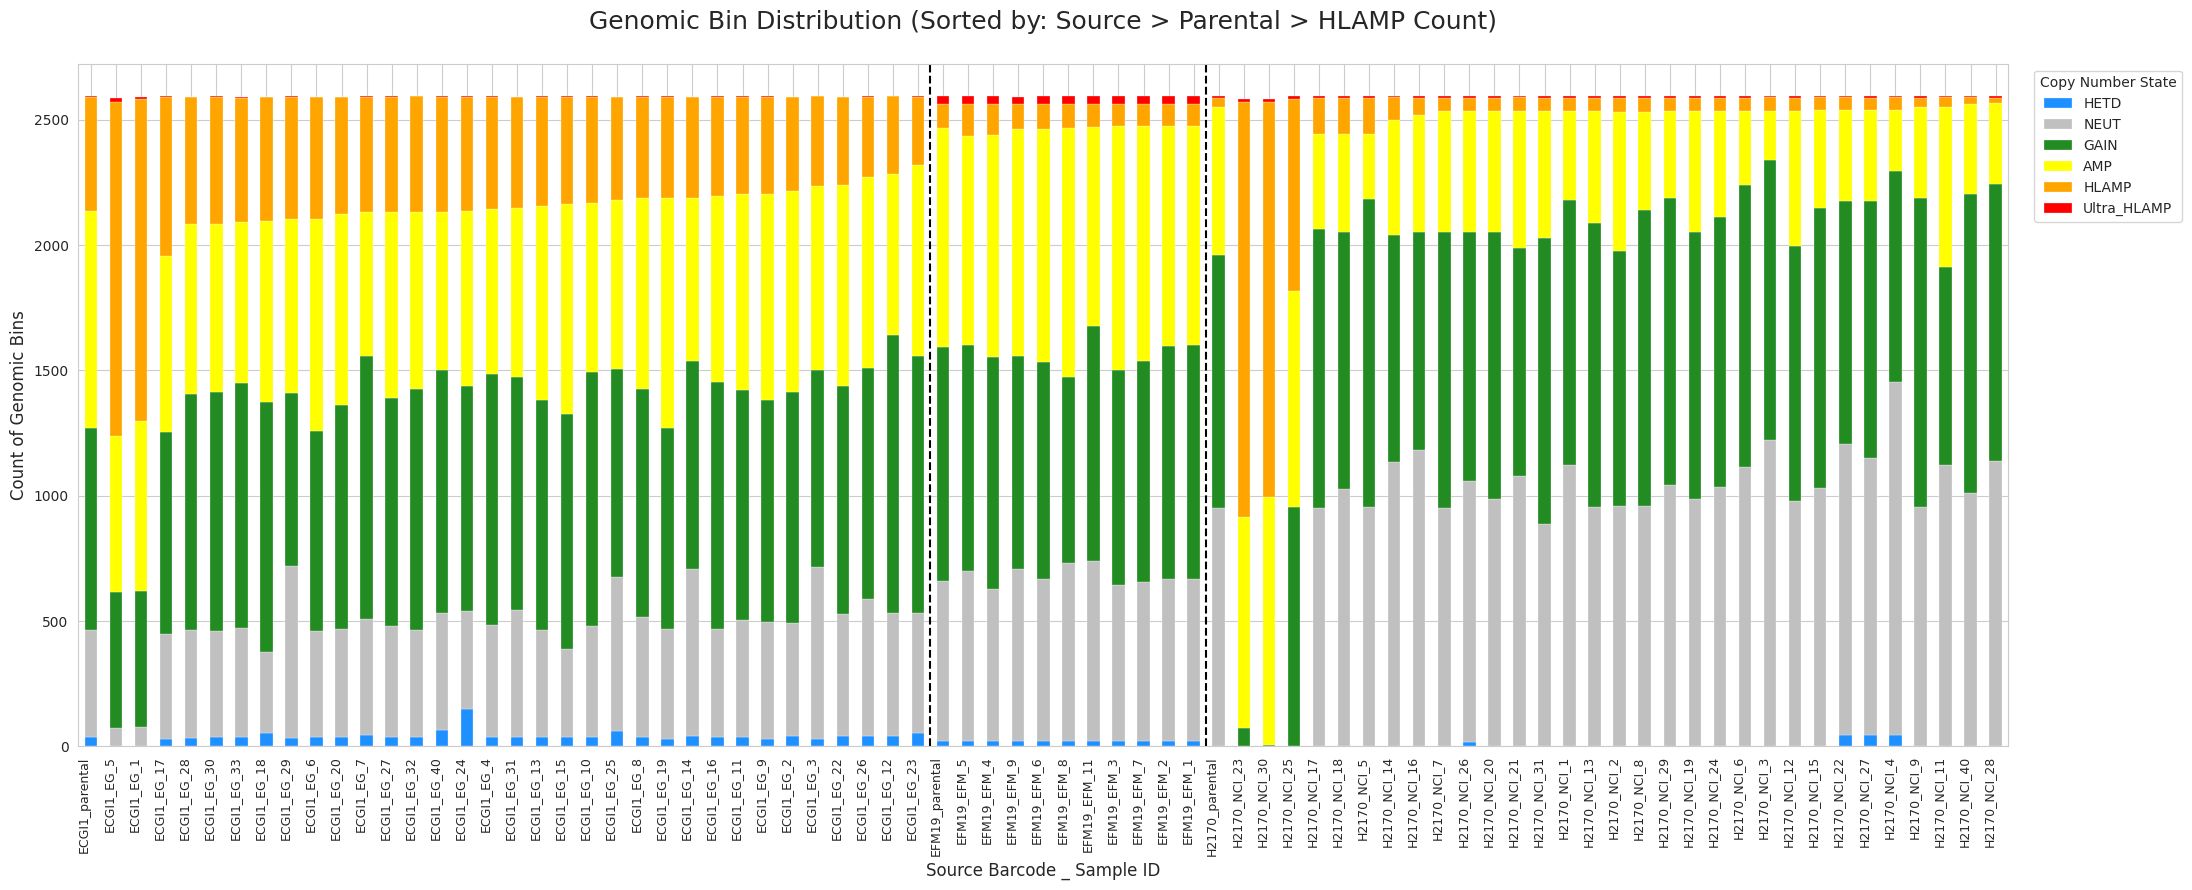

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 전처리: HLAMP2 통합
# cna_seg['Corrected_Call_2'] = cna_seg['Corrected_Call'].replace('HLAMP2', 'HLAMP')

# 2. 샘플별 HLAMP 빈도수 계산
# 각 샘플이 가진 HLAMP(빨간색) 구간의 개수를 미리 구합니다.
hlamp_counts = cna_seg[cna_seg['Reassigned_Event'] == 'HLAMP'].groupby(['source_barcode', 'sample_id']).size().reset_index(name='hlamp_count')

# 3. 전체 샘플 리스트와 HLAMP 카운트 병합 (HLAMP가 0인 샘플도 포함하기 위함)
sample_order_info = cna_seg[['source_barcode', 'sample_id']].drop_duplicates()
sample_order_info = pd.merge(sample_order_info, hlamp_counts, on=['source_barcode', 'sample_id'], how='left').fillna(0)

# 4. 정렬 로직 적용
# - 1순위: source_barcode (가나다/알파벳 순)
# - 2순위: Parental 여부 (Parental이면 0, 아니면 1 -> 0이 먼저 옴)
# - 3순위: HLAMP 카운트 (내림차순 정렬을 위해 마이너스 값을 사용하거나 아래 sort_values 활용)
sample_order_info['is_not_parental'] = sample_order_info['sample_id'].apply(
    lambda x: 0 if 'parental' in str(x).lower() else 1
)

# 정렬 실행: 소스별 -> 파렌탈 먼저 -> HLAMP 많은 순(False)
sample_order_info = sample_order_info.sort_values(
    by=['source_barcode', 'is_not_parental', 'hlamp_count'], 
    ascending=[True, True, False]
)

# 5. 최종 정렬된 라벨 생성
sample_order_info['plot_label'] = sample_order_info['source_barcode'] + "_" + sample_order_info['sample_id']
ordered_labels = sample_order_info['plot_label'].values

# 6. 교차표(Crosstab) 생성 및 순서 재배치
# 원본 데이터에도 plot_label 추가
cna_seg['plot_label'] = cna_seg['source_barcode'] + "_" + cna_seg['sample_id']

dist_table = pd.crosstab(index=cna_seg['plot_label'], 
                         columns=cna_seg['Reassigned_Event'], 
                         dropna=False)

# 위에서 정의한 순서(ordered_labels)대로 행 재배치 및 쌓는 순서(stack_order)대로 열 재배치
stack_order = ['HETD', 'NEUT', 'GAIN', 'AMP', 'HLAMP','Ultra_HLAMP']
existing_order = [col for col in stack_order if col in dist_table.columns]
dist_table = dist_table.reindex(index=ordered_labels, columns=existing_order)

# 7. 색상 매핑
color_map = {
    'HETD': 'dodgerblue', 'NEUT': 'silver', 'GAIN': 'forestgreen', 
    'AMP': 'yellow', 'HLAMP': 'orange', 'Ultra_HLAMP': 'red'
}
current_colors = [color_map[col] for col in existing_order]

# 8. 시각화
plt.figure(figsize=(25, 10))
ax = dist_table.plot(kind='bar', stacked=True, figsize=(22, 9), 
                     color=current_colors, edgecolor='white', linewidth=0.2)

# Source 그룹 구분을 위한 수직선 추가
current_source = ""
for i, label in enumerate(ordered_labels):
    source = label.split('_')[0]
    if current_source != "" and source != current_source:
        plt.axvline(x=i-0.5, color='black', linestyle='--', alpha=1, linewidth=1.5)
    current_source = source

plt.title('Genomic Bin Distribution (Sorted by: Source > Parental > HLAMP Count)', fontsize=18, pad=25)
plt.xlabel('Source Barcode _ Sample ID', fontsize=12)
plt.ylabel('Count of Genomic Bins', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.legend(title='Copy Number State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Here to change

In [33]:
cna_seg['source_barcode'].value_counts()

source_barcode
ECGI1    88196
H2170    83008
EFM19    28534
Name: count, dtype: int64

In [34]:
cna_seg.head(2)

source='ECGI1'
cna_seg_sub = cna_seg[cna_seg['source_barcode']==source].copy()

cna_seg_sub.head()

cna_seg_sub.columns

Index(['aliquot_barcode', 'chr', 'start', 'end', 'copy.number', 'event',
       'logR', 'subclone.status', 'Corrected_Copy_Number', 'Corrected_Call',
       'logR_Copy_Number', 'source_barcode', 'sample_id', 'old_source_barcode',
       'old_sample_id', 'Reassigned_Event', 'cgc_gene', 'cgc_gene_role',
       'plot_label'],
      dtype='object')

In [35]:
cna_seg_sub[cna_seg_sub['Corrected_Call']=='HLAMP']['Corrected_Copy_Number'].max()

cna_seg_sub[(cna_seg_sub['Corrected_Call']=='HLAMP2')&(cna_seg_sub['Corrected_Copy_Number']==6)]

cna_seg_sub[cna_seg_sub['Reassigned_Event']=='Unknown']

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,cgc_gene,cgc_gene_role,plot_label
90430,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,18,1,1000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_10,ECGI1,EG_10,Unknown,NaN,NaN,ECGI1_EG_10
91910,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,7,1000001,2000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_5,ECGI1,EG_5,Unknown,NaN,NaN,ECGI1_EG_5
91993,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,7,100000001,101000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_5,ECGI1,EG_5,Unknown,NaN,NaN,ECGI1_EG_5
92086,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,8,48000001,49000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_5,ECGI1,EG_5,Unknown,NaN,NaN,ECGI1_EG_5
92282,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,9,137000001,138000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_5,ECGI1,EG_5,Unknown,NaN,NaN,ECGI1_EG_5
92284,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,9,139000001,140000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_5,ECGI1,EG_5,Unknown,NaN,NaN,ECGI1_EG_5
93024,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,18,1,1000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_5,ECGI1,EG_5,Unknown,NaN,NaN,ECGI1_EG_5
93146,ECTRES-ECGI1-0001-TPX-A05-WGS-5FB937,20,1,1000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_5,ECGI1,EG_5,Unknown,NaN,NaN,ECGI1_EG_5
99692,ECTRES-ECGI1-0001-TPX-A24-WGS-9KH851,7,1000001,2000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_24,ECGI1,EG_24,Unknown,NaN,NaN,ECGI1_EG_24
102462,ECTRES-ECGI1-0001-TPX-A31-WGS-8UC862,8,48000001,49000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,ECGI1,EG_31,ECGI1,EG_31,Unknown,NaN,NaN,ECGI1_EG_31


In [50]:
cna_seg_sub[cna_seg_sub['Corrected_Call']=='AMP']['Corrected_Copy_Number'].max()


4.0

In [36]:
# HOMD Homozygous deletion, ≤ 0 copies
# HETD Heterozygous deletion, 1 copy
# NEUT Neutral change, 2 copies
# GAIN Gain of chromosome, 3 copies
# AMP Amplification event, 4 copies
# HLAMP High level amplification, < 15 copies
# Ultra-HLAMP High level amplification, ≥ 15 copies

In [37]:
pd.crosstab(index=cna_seg_sub['sample_id'], 
                                 columns=cna_seg_sub['Reassigned_Event'], 
                                 dropna=False)

Reassigned_Event,AMP,GAIN,HETD,HLAMP,NEUT,Ultra_HLAMP,Unknown
sample_id,,,,,,,
EG_1,677,542,0,1286,78,7,4
EG_10,677,1013,39,422,440,2,1
EG_11,782,918,39,388,465,1,1
EG_12,643,1107,41,309,493,1,0
EG_13,773,921,39,433,424,3,1
EG_14,651,830,43,401,666,1,2
EG_15,837,941,39,427,348,2,0
EG_16,740,988,39,397,428,2,0
EG_17,699,809,29,636,418,3,0


In [38]:
# 1. Corrected_Call별로 실제 수치 범위(Min, Max, Median) 한눈에 보기
summary = cna_seg_sub.groupby('Reassigned_Event')['Corrected_Copy_Number'].agg(['min', 'max', 'median', 'count'])
print("--- Event별 통계 요약 ---")
print(summary)

# 2. 특히 'HLAMP'이면서 초고수준 증폭(예: CN > 10)인 구간이 많은 샘플 찾기
extreme_amp = cna_seg_sub[cna_seg_sub['Corrected_Copy_Number'] > 10]
extreme_counts = extreme_amp.groupby('sample_id').size().sort_values(ascending=False)

print("\n--- 초고수준 증폭(CN > 10)이 가장 많은 샘플 Top 5 ---")
print(extreme_counts.head(5))

--- Event별 통계 요약 ---
                   min   max  median  count
Reassigned_Event                           
AMP                4.0   4.0     4.0  24712
GAIN               3.0   3.0     3.0  30377
HETD               1.0   1.0     1.0   1406
HLAMP              5.0  14.0     5.0  16378
NEUT               2.0   2.0     2.0  15195
Ultra_HLAMP       15.0  52.0    20.0     89
Unknown            NaN   NaN     NaN      0

--- 초고수준 증폭(CN > 10)이 가장 많은 샘플 Top 5 ---
sample_id
EG_5     42
EG_1     39
EG_25    19
EG_12    16
EG_2     15
dtype: int64


In [39]:
import pandas as pd

# 1. 염색체별로 각 Corrected_Call이 몇 번 나타나는지 집계
chr_dist = pd.crosstab(index=cna_seg_sub['chr'], 
                        columns=cna_seg_sub['Reassigned_Event'], 
                        dropna=False)

# 2. 'HLAMP'이 많은 순서대로 정렬해서 출력
print("--- 염색체별 Call 분포 (HLAMP 많은 순) ---")
print(chr_dist.sort_values(by='Ultra_HLAMP', ascending=False))

--- 염색체별 Call 분포 (HLAMP 많은 순) ---
Reassigned_Event   AMP  GAIN  HETD  HLAMP  NEUT  Ultra_HLAMP  Unknown
chr                                                                  
2                 3691  2427     0    460   936           34        0
8                 1018   843    28   2340   387           33        9
13                 335  1109    47    140  1486           11        0
9                  238  1027     0   2261     0            6        4
17                 954   166     0   1122     0            2        0
10                 165  2873     0    127   845            2        0
20                 734   460     0    647    90            1        6
22                 116   770     0     10   124            0        0
7                 2573   816    22    955   216            0        8
6                 2533  2101     0    600   172            0        0
5                 1329  2802     8   1158   313            0        0
4                  403  4074     0    201  1544         

In [40]:
# 복제수가 10 이상인 구간만 필터링 (ecDNA 의심 구간)
extreme_segments = cna_seg_sub[cna_seg_sub['Corrected_Copy_Number'] > 10]

# 주요 정보만 선택하여 출력 (상위 20개)
# 컬럼명은 데이터셋에 따라 'start', 'end' 등으로 다를 수 있으니 확인해 주세요.
print("\n--- 초고수준 증폭 구간 상세 위치 (Top 20) ---")
display_cols = ['sample_id', 'chr', 'start', 'end', 'Corrected_Copy_Number']
print(extreme_segments[display_cols].sort_values(by='Corrected_Copy_Number', ascending=False).head(20))


--- 초고수준 증폭 구간 상세 위치 (Top 20) ---
       sample_id chr      start        end  Corrected_Copy_Number
147136     EG_25  13   33000001   34000000                   52.0
91084       EG_5   2  103000001  104000000                   43.0
161122      EG_1   2  103000001  104000000                   42.0
134166      EG_8  13   33000001   34000000                   35.0
166310     EG_23   2  103000001  104000000                   34.0
127400     EG_11   2  103000001  104000000                   33.0
119618     EG_28   2  103000001  104000000                   33.0
163716      EG_6   2  103000001  104000000                   33.0
114430      EG_2   2  103000001  104000000                   33.0
142964     EG_16   2  103000001  104000000                   33.0
117024     EG_22   2  103000001  104000000                   33.0
109242     EG_19   2  103000001  104000000                   33.0
137776     EG_13   2  103000001  104000000                   33.0
168904  parental   2  103000001  10400000

In [41]:
cna_seg_sub.head(2)

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,cgc_gene,cgc_gene_role,plot_label
77820,ECTRES-H2170-0001-TPX-A10-WGS-8CY686,1,1000001,2000000,3,GAIN,NaN,0,3.0,GAIN,NaN,ECGI1,EG_40,H2170,NCI_10,GAIN,NaN,NaN,ECGI1_EG_40
77821,ECTRES-H2170-0001-TPX-A10-WGS-8CY686,1,2000001,3000000,3,GAIN,NaN,0,3.0,GAIN,NaN,ECGI1,EG_40,H2170,NCI_10,GAIN,NaN,NaN,ECGI1_EG_40


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = cna_seg_sub.copy()
# 1. 데이터 로드 (이미 불러오신 데이터프레임을 df라고 가정)
# bin_id를 생성하여 고유한 유전체 위치 정의
df['bin_id'] = df['chr'].astype(str) + ":" + df['start'].astype(str) + "-" + df['end'].astype(str)

# 2. Pivot Table 만들기
# index: 샘플, columns: 유전체 위치, values: 복제수(또는 logR)
pivot_df = df.pivot(index='sample_id', columns='bin_id', values='Corrected_Copy_Number')

# 3. 유전체 순서대로 컬럼 정렬 (매우 중요!)
# chr1 -> chr2 ... 순서로 정렬되지 않으면 Heatmap이 엉망이 됩니다.
# 원본 데이터에서 순서를 추출합니다.
bin_order = df[['bin_id', 'chr', 'start']].drop_duplicates().sort_values(['chr', 'start'])['bin_id']
pivot_df = pivot_df[bin_order]

# 4. 분석을 위해 source_barcode 정보 다시 붙이기
# (pivot 과정에서 index가 되었으므로 mapping table 필요)
sample_map = df[['sample_id', 'source_barcode']].drop_duplicates().set_index('sample_id')
pivot_df['source_barcode'] = sample_map['source_barcode']

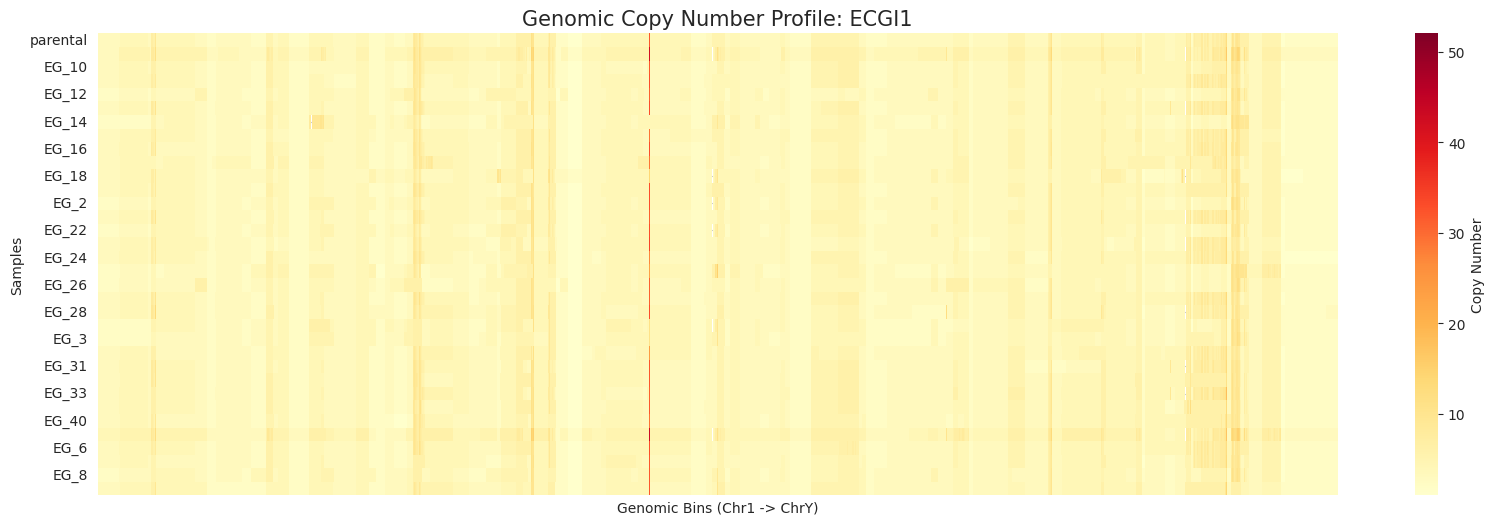

In [43]:
# 색상 지정 (보내주신 이전 차트의 HLAMP/AMP 색상과 맞춤)
# 0: NEUT/HETD, 3: AMP, 4: HLAMP 등 수치에 맞춰 매핑
cmap = {0: '#BDC3C7', 1: '#BDC3C7', 2: '#BDC3C7', 3: '#FFA500', 4: '#FF0000'}

for source in pivot_df['source_barcode'].unique():
    subset = pivot_df[pivot_df['source_barcode'] == source].drop(columns='source_barcode')
    
    # Parental 샘플이 있다면 맨 위로 정렬 (샘플명에 'parental'이 포함된 경우)
    rows = subset.index.tolist()
    parental_rows = [r for r in rows if 'parental' in r.lower()]
    clone_rows = [r for r in rows if 'parental' not in r.lower()]
    subset = subset.reindex(parental_rows + clone_rows)

    plt.figure(figsize=(20, 6))
    # annot=False로 해야 속도가 빠릅니다. 
    sns.heatmap(subset, cmap="YlOrRd", cbar_kws={'label': 'Copy Number'})
    
    plt.title(f"Genomic Copy Number Profile: {source}", fontsize=15)
    plt.xlabel("Genomic Bins (Chr1 -> ChrY)")
    plt.ylabel("Samples")
    plt.xticks([]) # Bin이 너무 많으므로 x축 눈금은 제거
    plt.show()

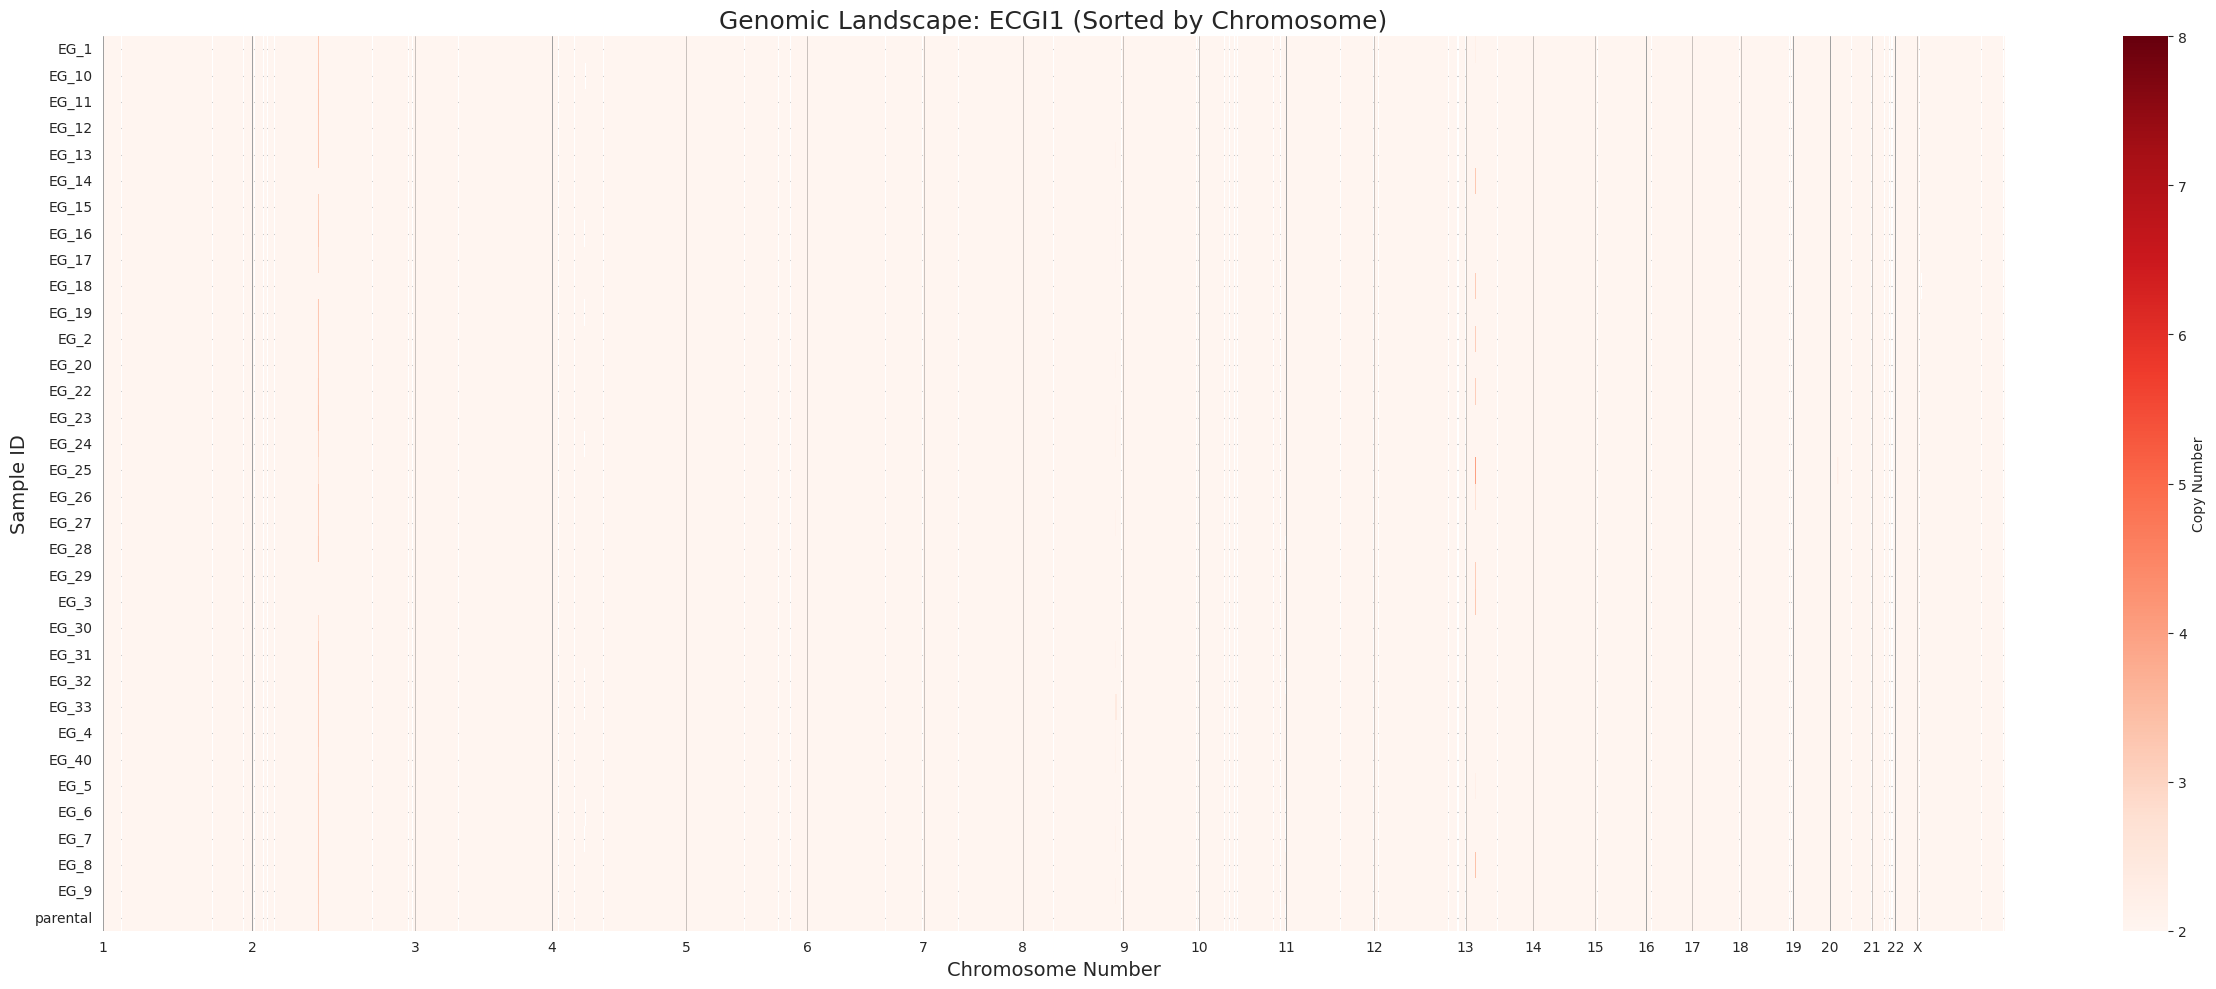

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 사용자 설정 ---
# target_source = "ECGI1" 
# -----------------

# 1. 특정 계통 필터링
# df_sub = df[df['source_barcode'] == target_source].copy()
df_sub = cna_seg_sub.copy()

# 2. Chromosome 정렬 순서 정의 (1~22, X, Y)
# 숫자로 변환 가능한 건 숫자로, X/Y는 뒤로 보냅니다.
def chr_sort_key(chr_name):
    c = str(chr_name).replace('chr', '').replace('Chr', '')
    if c == 'X': return 23
    if c == 'Y': return 24
    try:
        return int(c)
    except ValueError:
        return 99

df_sub['chr_num'] = df_sub['chr'].apply(chr_sort_key)
df_sub = df_sub.sort_values(['chr_num', 'start'])

# 3. Bin ID 생성 및 Pivot (Y축: sample_id)
# f-string을 써서 정렬된 순서대로 bin_id가 생성되게 합니다.
df_sub['bin_id'] = df_sub['chr'].astype(str) + ":" + df_sub['start'].astype(str)
pivot_df = df_sub.pivot(index='sample_id', columns='bin_id', values='logR')

# 4. Pivot 이후에도 컬럼 순서가 뒤섞이지 않게 재정렬
sorted_bins = df_sub['bin_id'].unique()
pivot_df = pivot_df.reindex(columns=sorted_bins)

# 5. X축 Chromosome 라벨 및 구분선 위치 계산
chr_ticks = []
chr_labels = []
last_chr = None

for i, bin_id in enumerate(sorted_bins):
    current_chr = bin_id.split(':')[0]
    if current_chr != last_chr:
        chr_ticks.append(i)
        chr_labels.append(current_chr.replace('chr', ''))
        last_chr = current_chr
        
        
plt.figure(figsize=(25, 10))

# 0~2(정상/낮음), 3(AMP), 4(HLAMP) 분포에 최적화된 컬러맵
# sns.heatmap(pivot_df, 
#             cmap="YlOrRd", 
#             cbar_kws={'label': 'Copy Number'},
#             yticklabels=True,
#             xticklabels=False) # 개별 Bin 라벨은 숨김
sns.heatmap(pivot_df, 
            cmap="Reds",        # White to Red 기본 컬러맵
            vmin=2,             # 2(정상) 이하를 흰색에 가깝게 처리
            vmax=8,             # 5 이상을 가장 진한 빨강으로 처리
            cbar_kws={'label': 'Copy Number'},
            yticklabels=True,
            xticklabels=False)

# X축에 염색체 번호 표시 (중앙 정렬을 위해 각 구간의 중간 지점으로 계산 가능하나 우선 시작점 표시)
plt.xticks(chr_ticks, chr_labels, fontsize=10)

# 염색체 경계선 (수직선) 추가 - 구분이 훨씬 명확해집니다.
for tick in chr_ticks:
    plt.axvline(x=tick, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

plt.title(f"Genomic Landscape: {source} (Sorted by Chromosome)", fontsize=18)
plt.xlabel("Chromosome Number", fontsize=14)
plt.ylabel("Sample ID", fontsize=14)

plt.tight_layout()
plt.show()

In [45]:
aaSuite_gemline_ms=pd.read_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all_20260327.csv')
aaSuite_gemline_ms_sub=aaSuite_gemline_ms[aaSuite_gemline_ms['source_barcode']==source]
aaSuite_gemline_ms_sub.shape


(1511, 28)

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_aa = aaSuite_gemline_ms_sub.copy()
# ---------------------------------------------------------
# 1. Parental의 ecDNA Interval 추출 및 파싱
# ---------------------------------------------------------
# df_aa는 AmpliconArchitect 결과가 담긴 데이터프레임이라고 가정합니다.
intervals_series = df_aa[(df_aa['sample_id'] == 'parental') & (df_aa['amplicon_type'] == 'ecDNA')]['Intervals']
# intervals_series = df_aa[(df_aa['sample_id'] == 'parental') & (df_aa['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False))]['Intervals']
print(intervals_series)

# 여러 행에 걸쳐 있을 수 있으므로 콤마로 모두 합친 후 리스트로 만듭니다.
all_intervals_str = ",".join(intervals_series.dropna().astype(str))

ecdna_regions = []
for inv in all_intervals_str.split(','):
    inv = inv.strip()
    if not inv: continue
    
    # "8:43225919-43227230" 형태 분리
    chrom, pos = inv.split(':')
    start, end = pos.split('-')
    
    # 'chr' 접두사 통일 (매핑을 위해)
    chrom = chrom.replace('chr', '') 
    ecdna_regions.append((chrom, int(start), int(end)))

# ---------------------------------------------------------
# 2. ichorCNA Segment 데이터 필터링 (Overlap 확인)
# ---------------------------------------------------------
df_sub = cna_seg_sub.copy() # 원본 cna_seg 데이터
# df_sub = df.copy() # 원본 cna_seg 데이터

df_sub['chr_clean'] = df_sub['chr'].astype(str).str.replace('chr', '')

def check_overlap(row_chr, row_start, row_end, regions):
    for (r_chr, r_start, r_end) in regions:
        if str(row_chr) == str(r_chr):
            # 두 구간이 겹치는지 확인하는 공식: max(start1, start2) <= min(end1, end2)
            if max(row_start, r_start) <= min(row_end, r_end):
                return True
    return False

# Overlap 되는 Bin만 남기기
df_sub['is_ecDNA_target'] = df_sub.apply(lambda row: check_overlap(row['chr_clean'], row['start'], row['end'], ecdna_regions), axis=1)
df_target = df_sub[df_sub['is_ecDNA_target']].copy()

print(f"매핑된 ecDNA 관련 Bin 개수: {len(df_target['start'].unique())}개")
print(df_target.shape)

2361                                     1:840697-2224739
2374            14:20114992-29629946,14:97971068-97971919
2388                                1:153359512-153419512
2389    1:158899322-162244209,8:68079123-68079974,11:1...
Name: Intervals, dtype: object
매핑된 ecDNA 관련 Bin 개수: 19개
(646, 21)


In [47]:
# df_target.columns
# df_target['chr'].unique()
# df_target[df_target['sample_id']=='parental']['chr'].unique()

# df_aa[df_aa['sample_id']=='parental'].head(2)

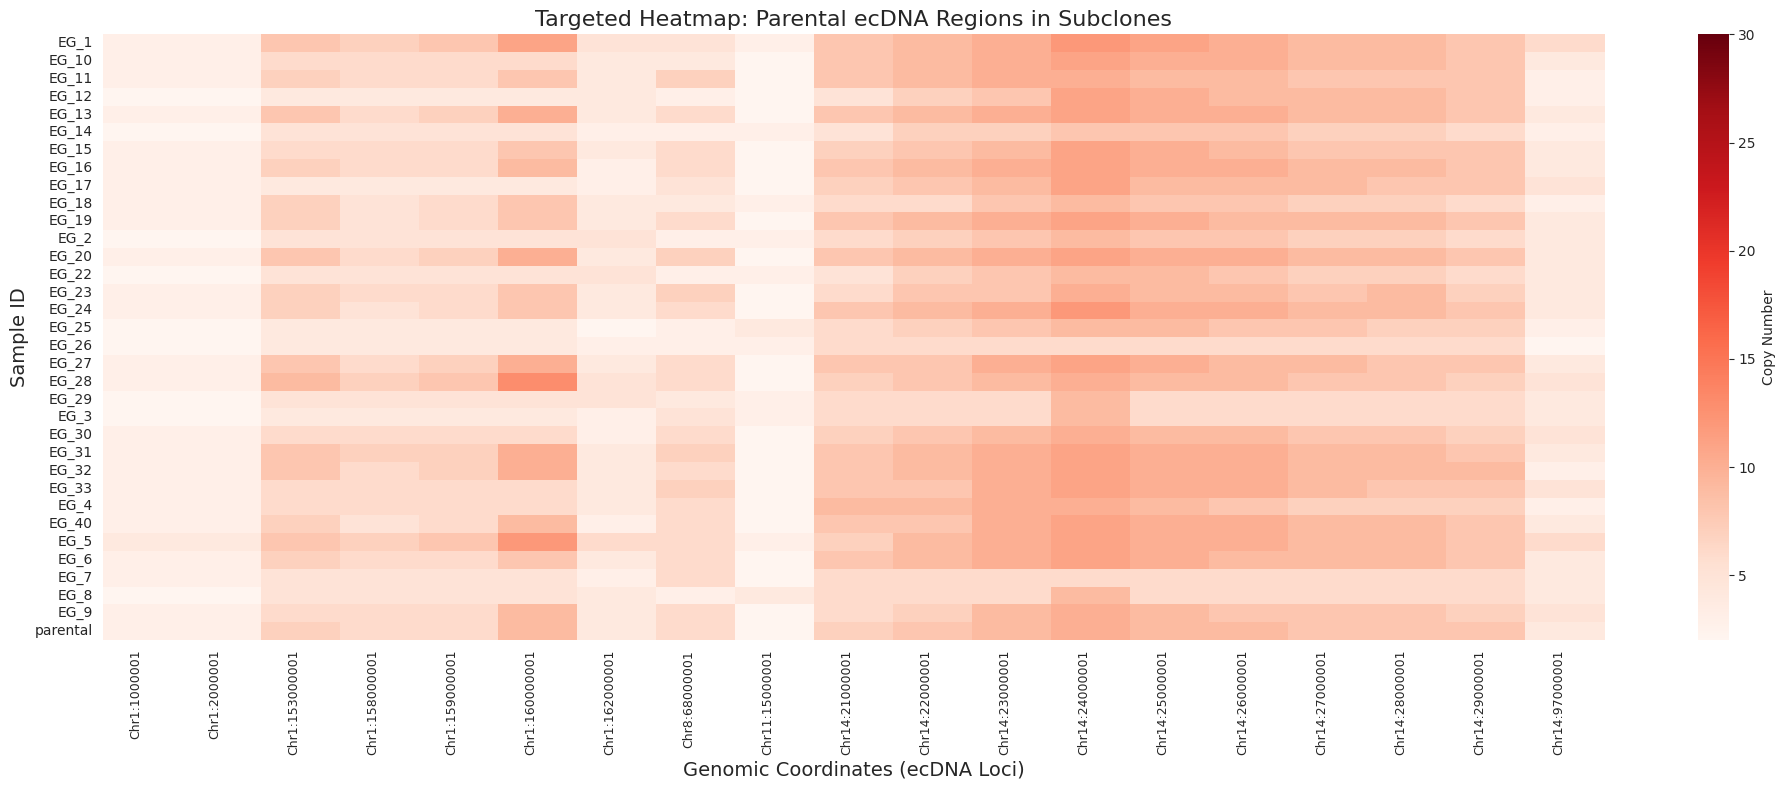

In [48]:
# ---------------------------------------------------------
# 3. 데이터 정렬 및 Pivot (Zoom-in 전용)
# ---------------------------------------------------------
def chr_sort_key(chr_name):
    c = str(chr_name)
    if c == 'X': return 23
    if c == 'Y': return 24
    try: return int(c)
    except ValueError: return 99

df_target['chr_num'] = df_target['chr_clean'].apply(chr_sort_key)
df_target = df_target.sort_values(['chr_num', 'start'])

# Bin ID 생성
df_target['bin_id'] = "Chr" + df_target['chr_clean'] + ":" + df_target['start'].astype(str)
pivot_df = df_target.pivot(index='sample_id', columns='bin_id', values='Corrected_Copy_Number')

# Pivot 후 컬럼 순서 재정렬
sorted_bins = df_target['bin_id'].unique()
pivot_df = pivot_df.reindex(columns=sorted_bins)

# ---------------------------------------------------------
# 4. Zoom-in Heatmap 시각화
# ---------------------------------------------------------
plt.figure(figsize=(20, 8))

# White to Red 컬러맵 적용 (2 이하를 흰색으로 날리고 증폭된 곳만 강조)
sns.heatmap(pivot_df, 
            cmap="Reds", 
            vmin=2,  
            vmax=30, # 최대 Copy Number에 맞게 조절하세요 (HLAMP가 4 이상이라면 6~10 정도가 적당)
            cbar_kws={'label': 'Copy Number'},
            yticklabels=True,
            xticklabels=True) # 확대 뷰이므로 개별 Bin 라벨을 켭니다!

# X축 라벨 회전 (글씨가 겹치지 않게)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=10)

target_source = df_target['source_barcode'].iloc[0] if not df_target.empty else "Unknown"
plt.title(f"Targeted Heatmap: Parental ecDNA Regions in Subclones", fontsize=16)
plt.xlabel("Genomic Coordinates (ecDNA Loci)", fontsize=14)
plt.ylabel("Sample ID", fontsize=14)

# Parental을 위로 올리고 싶다면 (선택사항)
# rows = pivot_df.index.tolist()
# rows.sort(key=lambda x: (0 if 'parental' in x.lower() else 1, x))
# pivot_df = pivot_df.reindex(rows)

plt.tight_layout()
plt.show()

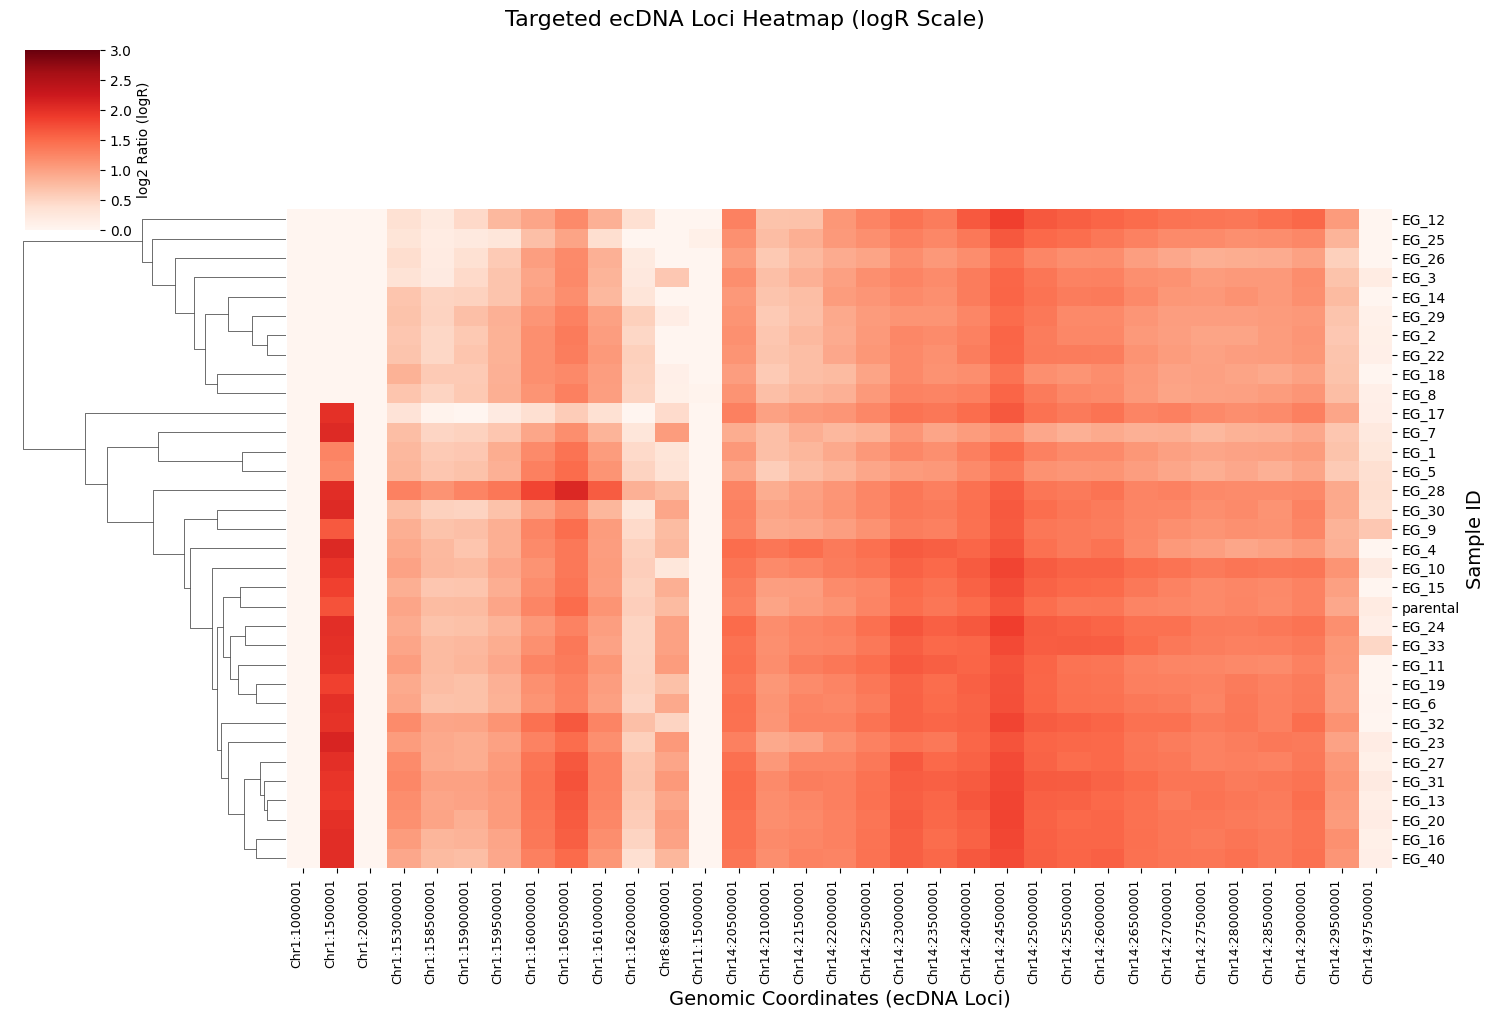

In [397]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. logR 값을 기준으로 Pivot 생성 및 전처리 (에러 방지용)
pivot_df_logR = df_target.pivot(index='sample_id', columns='bin_id', values='logR')
pivot_df_logR = pivot_df_logR.reindex(columns=sorted_bins)
pivot_df_logR = pivot_df_logR.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# 2. Clustermap 시각화 (Y축 sample_id만 클러스터링!)
# plt.figure(figsize) 대신 clustermap 안에서 figsize를 지정합니다.
cg = sns.clustermap(pivot_df_logR, 
                    row_cluster=True,   # 🟢 Y축(Sample ID) 클러스터링 켜기 (트리 생성)
                    col_cluster=False,  # 🔴 X축(Genomic Bins) 클러스터링 끄기 (순서 그대로)
                    cmap="Reds", 
                    vmin=0, 
                    vmax=3, 
                    figsize=(15, 10),
                    cbar_kws={'label': 'log2 Ratio (logR)'})

# 3. 축 라벨 회전 및 폰트 설정 (clustermap은 ax_heatmap 객체에 적용해야 함)
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xmajorticklabels(), rotation=90, ha='right', fontsize=9)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=10)

# 4. 타이틀 및 축 이름 설정
cg.fig.suptitle("Targeted ecDNA Loci Heatmap (logR Scale)", fontsize=16, y=1.02)
cg.ax_heatmap.set_xlabel("Genomic Coordinates (ecDNA Loci)", fontsize=14)
cg.ax_heatmap.set_ylabel("Sample ID", fontsize=14)

plt.show()

In [398]:
import pandas as pd
from scipy.cluster.hierarchy import fcluster

# 1. Clustermap 객체(cg)에서 덴드로그램 연결 정보(Linkage matrix) 가져오기
Z = cg.dendrogram_row.linkage

# 2. 샘플들을 몇 개의 큰 덩어리(Cluster)로 나눌지 설정 (예: 3개)
# 원하시는 그룹 개수에 맞춰 숫자를 수정하세요.
num_clusters = 5 
cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')

# 3. 원래 데이터의 인덱스(sample_id)와 클러스터 라벨을 매칭하여 데이터프레임 생성
cluster_table = pd.DataFrame({
    'sample_id': pivot_df_logR.index,
    'Cluster_Group': cluster_labels
})

# 4. Heatmap의 Y축(위에서 아래)에 표시된 순서대로 추출
ordered_indices = cg.dendrogram_row.reordered_ind
ordered_samples = pivot_df_logR.index[ordered_indices]

# 5. 보기 좋게 정렬하여 최종 표 완성
cluster_table['Y_axis_Order'] = cluster_table['sample_id'].apply(lambda x: list(ordered_samples).index(x))
final_cluster_table = cluster_table.sort_values('Y_axis_Order').reset_index(drop=True)

# 표 출력
print(final_cluster_table)

   sample_id  Cluster_Group  Y_axis_Order
0      EG_12              2             0
1      EG_25              1             1
2      EG_26              1             2
3       EG_3              1             3
4      EG_14              1             4
5      EG_29              1             5
6       EG_2              1             6
7      EG_22              1             7
8      EG_18              1             8
9       EG_8              1             9
10     EG_17              5            10
11      EG_7              3            11
12      EG_1              3            12
13      EG_5              3            13
14     EG_28              4            14
15     EG_30              4            15
16      EG_9              4            16
17      EG_4              4            17
18     EG_10              4            18
19     EG_15              4            19
20  parental              4            20
21     EG_24              4            21
22     EG_33              4       

In [399]:
# final_cluster_table_erbb2=final_cluster_table.copy()
final_cluster_table_erbb2

,sample_id,Cluster_Group,Y_axis_Order
0,NCI_27,1,0
1,NCI_15,1,1
2,NCI_22,1,2
3,NCI_4,1,3
4,NCI_11,2,4
5,NCI_28,2,5
6,NCI_1,3,6
7,NCI_2,3,7
8,NCI_8,3,8
9,NCI_29,4,9


In [400]:
df_target['logR'].max()

2.1136

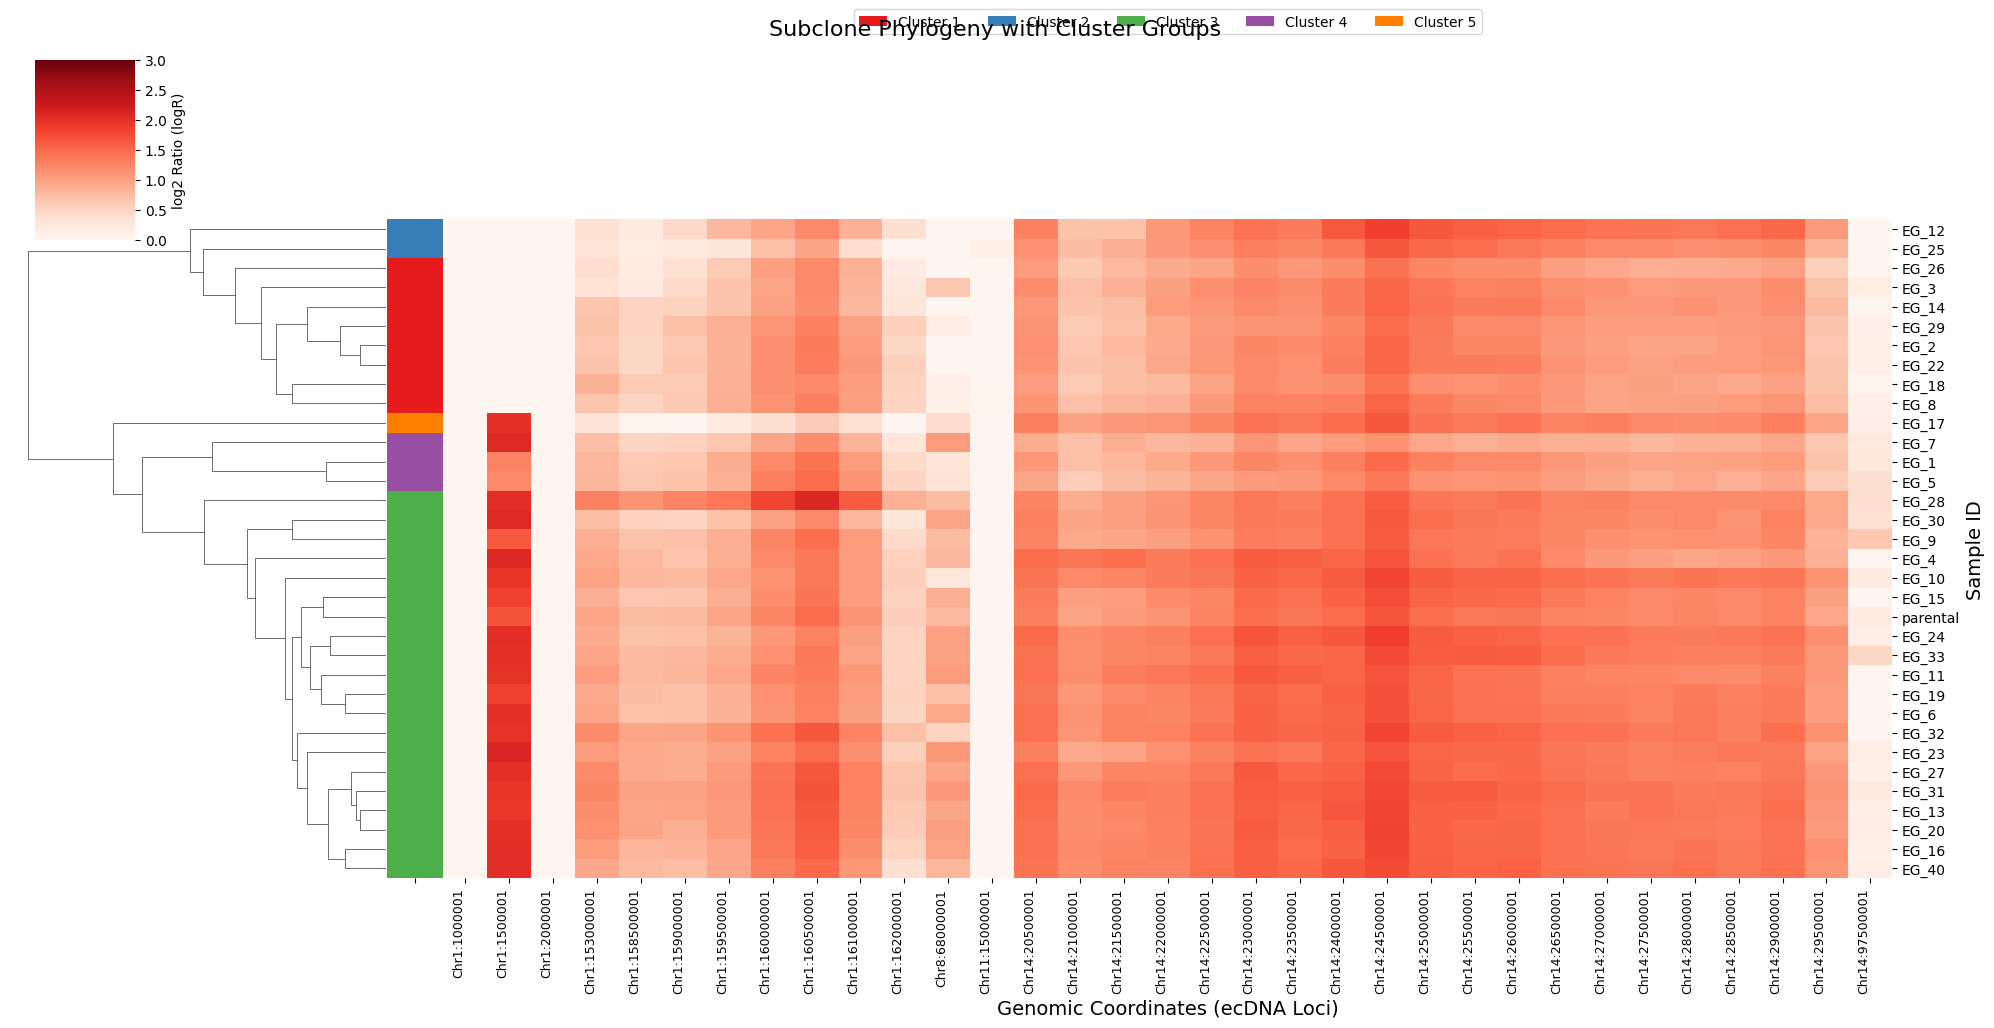

In [401]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster

# 1. 데이터 준비 및 전처리 (이전과 동일)
pivot_df_logR = df_target.pivot(index='sample_id', columns='bin_id', values='logR')
pivot_df_logR = pivot_df_logR.reindex(columns=sorted_bins)
pivot_df_logR = pivot_df_logR.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# ---------------------------------------------------------
# 2. 클러스터링 계산 및 색상 매핑 (💡 새로 추가된 부분)
# ---------------------------------------------------------
# 샘플 간의 거리 계산 및 계통 연결 (Ward 방식 사용)
Z = linkage(pivot_df_logR, method='ward')

# 몇 개의 클러스터로 나눌지 설정 (예: 3개)
num_clusters = 5
cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')

# 클러스터 그룹별로 할당할 색상 팔레트 생성 (예: Set1, Set2 등)
palette = sns.color_palette("Set1", num_clusters)

# 각 샘플(인덱스)이 어떤 색상을 가져야 하는지 딕셔너리로 매핑
# cluster_labels는 1부터 시작하므로 인덱스 맞추기 위해 -1을 해줍니다.
lut = dict(zip(range(1, num_clusters + 1), palette))
row_colors = pd.Series(cluster_labels, index=pivot_df_logR.index).map(lut)

# ---------------------------------------------------------
# 3. Clustermap 시각화 (row_colors 파라미터 추가!)
# ---------------------------------------------------------
cg = sns.clustermap(pivot_df_logR, 
                    row_cluster=True,   # Y축 덴드로그램 켜기
                    col_cluster=False,  # X축 클러스터링 끄기
                    row_colors=row_colors, # 💡 여기에 생성한 색상 띠를 넣어줍니다!
                    cmap="Reds", 
                    vmin=0, 
                    vmax=3, 
                    figsize=(20, 10),
                    cbar_kws={'label': 'log2 Ratio (logR)'})

# 4. 라벨 및 타이틀 세팅
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xmajorticklabels(), rotation=90, ha='right', fontsize=9)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=10)

cg.ax_heatmap.set_xlabel("Genomic Coordinates (ecDNA Loci)", fontsize=14)
cg.ax_heatmap.set_ylabel("Sample ID", fontsize=14)
cg.fig.suptitle("Subclone Phylogeny with Cluster Groups", fontsize=16, y=1.02)

# 5. 범례(Legend) 추가 (어떤 색이 몇 번 그룹인지 표시)
for label, color in lut.items():
    cg.ax_col_dendrogram.bar(0, 0, color=color, label=f'Cluster {label}', linewidth=0)
cg.ax_col_dendrogram.legend(loc="center", ncol=num_clusters, bbox_to_anchor=(0.5, 1.2))

plt.show()

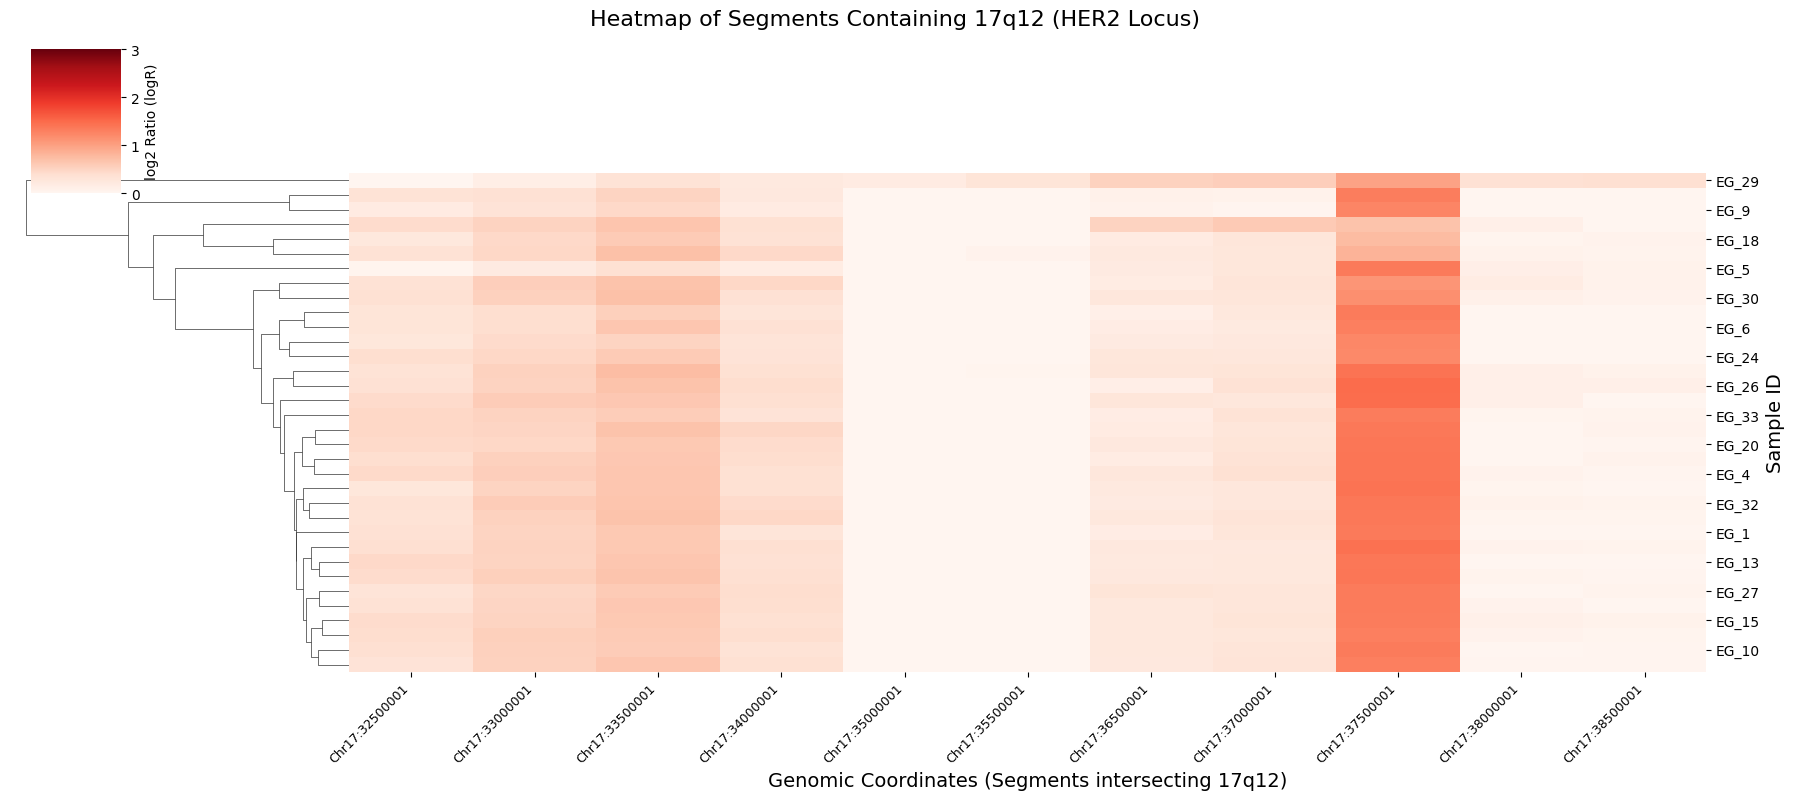

In [402]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 17q12 타깃 구역 좌표 설정 ---
target_chr = '17'
# 레퍼런스(hg19/hg38)에 따라 약간 다를 수 있으나, 대략적인 17q12 영역 설정
region_start = 33000000 
region_end = 39000000   

# --- 2. 타깃 구역을 '포함하거나 겹치는' Segment 필터링 ---
df_zoom = cna_seg_sub.copy()
df_zoom['chr_clean'] = df_zoom['chr'].astype(str).str.replace('chr', '')

# 💡 핵심 로직: Segment의 시작점이 타깃의 끝점보다 앞서고, Segment의 끝점이 타깃의 시작점보다 뒤에 있으면 겹침(Overlap)!
overlap_condition = (
    (df_zoom['chr_clean'] == target_chr) & 
    (df_zoom['start'] <= region_end) & 
    (df_zoom['end'] >= region_start)
)
df_17q12_segments = df_zoom[overlap_condition].copy()

# --- 3. Bin ID 생성 및 Pivot ---
# Segment가 한눈에 보이도록 start 좌표를 기준으로 Bin ID 생성
df_17q12_segments['bin_id'] = "Chr" + df_17q12_segments['chr_clean'] + ":" + df_17q12_segments['start'].astype(str)

# X축 순서대로 정렬하기 위해 start 좌표 기준으로 Bin 순서 고정
sorted_bins_17q12 = df_17q12_segments[['bin_id', 'start']].drop_duplicates().sort_values('start')['bin_id']

# Pivot Table 생성 (values는 logR 사용)
pivot_df_17q12 = df_17q12_segments.pivot(index='sample_id', columns='bin_id', values='logR')
pivot_df_17q12 = pivot_df_17q12.reindex(columns=sorted_bins_17q12)

# 클러스터링 에러 방지 (결측치 및 무한대 값 0으로 치환)
pivot_df_17q12 = pivot_df_17q12.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# --- 4. Clustermap 시각화 ---
cg = sns.clustermap(pivot_df_17q12, 
                    row_cluster=True,   # Y축(샘플) 클러스터링 켜기
                    col_cluster=False,  # X축(염기서열) 순서 유지
                    cmap="Reds", 
                    vmin=0, 
                    vmax=3, 
                    figsize=(18, 8),    # X축이 길어질 수 있으므로 가로 비율 확보
                    cbar_kws={'label': 'log2 Ratio (logR)'})

# 축 라벨 및 폰트 세팅
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xmajorticklabels(), rotation=45, ha='right', fontsize=9)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=10)

cg.ax_heatmap.set_xlabel("Genomic Coordinates (Segments intersecting 17q12)", fontsize=14)
cg.ax_heatmap.set_ylabel("Sample ID", fontsize=14)
cg.fig.suptitle("Heatmap of Segments Containing 17q12 (HER2 Locus)", fontsize=16, y=1.03)

plt.show()

In [403]:
cna_seg_sub.head()

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label,cgc_gene,cgc_gene_role
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,1000001,1500000,4,AMP,NaN,0,4.0,AMP,NaN,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,1500001,2000000,4,AMP,1.2606,0,13.0,HLAMP,12.606763,ECGI1,EG_1,ECGI1,EG_1,HLAMP,ECGI1_EG_1,None,None
2,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,2000001,2500000,4,AMP,NaN,0,4.0,AMP,NaN,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN
3,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,3000001,3500000,4,AMP,-0.1235,0,4.0,AMP,4.830009,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN
4,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,4000001,4500000,4,AMP,0.4478,0,4.0,AMP,7.176726,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN


In [404]:
final_cluster_table.to_csv(f'../summary/ichorCNA/ichorCNA_cna_seg_cluster_{source}_20260331.csv', index=False)
# ichor_df.to_csv('../summary/ichorCNA_summary_params_20260331.csv', index=False)


In [405]:
df.head()

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label,cgc_gene,cgc_gene_role,bin_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,1000001,1500000,4,AMP,NaN,0,4.0,AMP,NaN,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN,1:1000001-1500000
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,1500001,2000000,4,AMP,1.2606,0,13.0,HLAMP,12.606763,ECGI1,EG_1,ECGI1,EG_1,HLAMP,ECGI1_EG_1,None,None,1:1500001-2000000
2,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,2000001,2500000,4,AMP,NaN,0,4.0,AMP,NaN,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN,1:2000001-2500000
3,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,3000001,3500000,4,AMP,-0.1235,0,4.0,AMP,4.830009,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN,1:3000001-3500000
4,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,4000001,4500000,4,AMP,0.4478,0,4.0,AMP,7.176726,ECGI1,EG_1,ECGI1,EG_1,AMP,ECGI1_EG_1,NaN,NaN,1:4000001-4500000


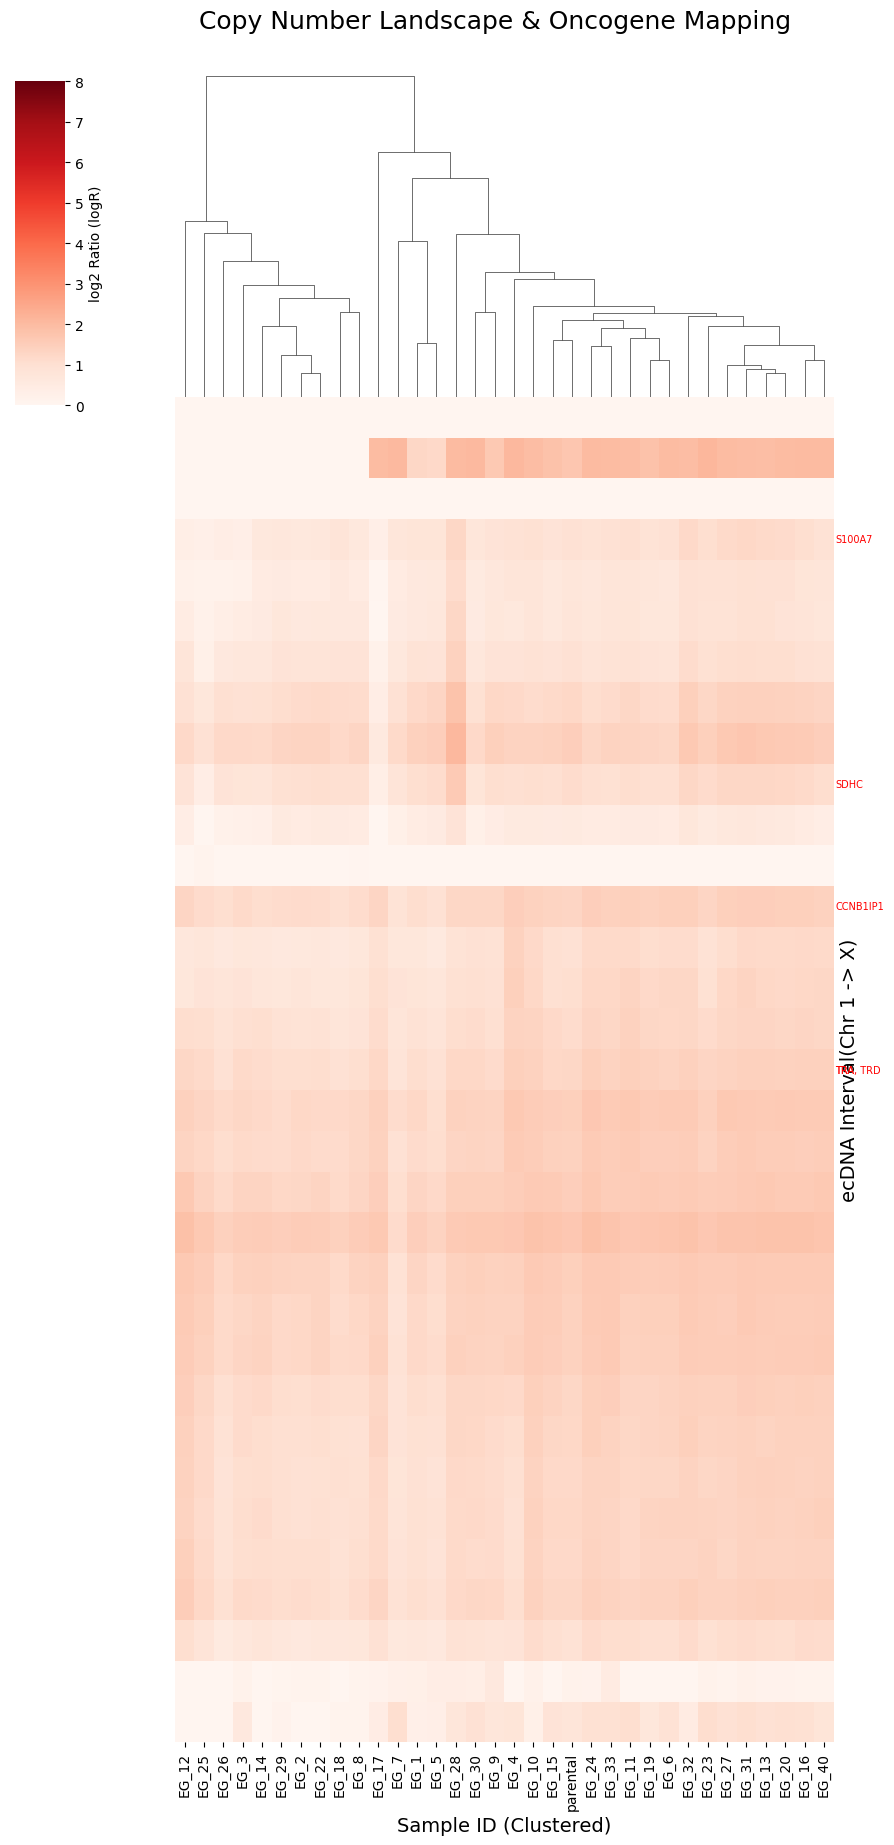

In [406]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = df_target.copy()

# ---------------------------------------------------------
# 1. 데이터 준비 및 Bin ID "재생성" (에러 방지 핵심!)
# ---------------------------------------------------------
# 필터링하면서 날아갔을 수 있으니 무조건 다시 만들어줍니다.
df['bin_id'] = "Chr" + df['chr'].astype(str) + ":" + df['start'].astype(str)
df['start_num'] = df['start'].astype(float)

# 유전체 순서대로 Bin 정렬
sorted_bins = df[['chr', 'start_num', 'bin_id']].drop_duplicates() \
                .sort_values(['chr', 'start_num'])['bin_id'].tolist()

# ---------------------------------------------------------
# 2. Pivot Table 생성 (중복값은 평균으로 처리해서 에러 방지)
# ---------------------------------------------------------
pivot_df_T = df.pivot_table(index='bin_id', 
                                  columns='sample_id', 
                                  values='logR', 
                                  aggfunc='mean')

# 유전체 순서 강제 고정 및 결측치 0으로 치환
pivot_df_T = pivot_df_T.reindex(index=sorted_bins) 
pivot_df_T = pivot_df_T.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# ---------------------------------------------------------
# 3. Clustermap 시각화 (X-Y축 반전)
# ---------------------------------------------------------
cg = sns.clustermap(pivot_df_T, 
                    row_cluster=False,  # Y축(유전체 좌표) 순서 고정!
                    col_cluster=True,   # X축(샘플) 클러스터링으로 계통 묶기!
                    cmap="Reds", 
                    vmin=0, vmax=8, 
                    figsize=(10, 18),   # 세로로 길게
                    cbar_kws={'label': 'log2 Ratio (logR)'})



# Y축 라벨 지우기 (수만 개라 까맣게 뭉치는 현상 방지)
cg.ax_heatmap.set_yticks([]) 

# ---------------------------------------------------------
# 4. Y축 오른쪽에 Oncogene 이름(cgc_gene) 텍스트 매핑하기
# ---------------------------------------------------------
# cgc_gene 컬럼에 값이 있는(매핑된) 알짜배기 데이터만 추출
# ---------------------------------------------------------
# 4. Y축 오른쪽에 Oncogene 이름(cgc_gene) 텍스트 매핑하기
# ---------------------------------------------------------
# cgc_gene 컬럼에 값이 있는(매핑된) 알짜배기 데이터만 추출
df_annotated = df.dropna(subset=['cgc_gene']).copy() 

gene_y_positions = {}
for _, row in df_annotated.iterrows():
    bin_id = row['bin_id']
    
    # 💡 수정된 부분: split()으로 쪼개지 않고 통째로 가져옵니다! 
    # (예: "EGFR, MYC" 형태 그대로 유지)
    gene_str = row['cgc_gene'] 
    
    if bin_id in sorted_bins:
        y_pos = sorted_bins.index(bin_id)
        # 통째로 된 문자열을 key로 사용
        if gene_str not in gene_y_positions:
            gene_y_positions[gene_str] = []
        gene_y_positions[gene_str].append(y_pos)

# 텍스트 달아주기
x_max = pivot_df_T.shape[1] 

for gene_str, y_coords in gene_y_positions.items():
    # 여러 Bin에 걸쳐 있다면 중앙값(Median)에 예쁘게 하나만 달아줌
    median_y = np.median(y_coords) + 0.5 
    
    cg.ax_heatmap.text(x=x_max + 0.1, 
                       y=median_y, 
                       s=gene_str,  # 쪼개지지 않은 전체 유전자 문자열 출력
                       va='center', 
                       ha='left', 
                       color='red', 
                       fontsize=7,
                       rotation=0) # 💡 만약 글씨가 겹치면 이 부분을 45 로 바꿔주세요!
# ---------------------------------------------------------
# 5. 축 라벨 및 타이틀 세팅
# ---------------------------------------------------------
cg.ax_heatmap.set_xlabel("Sample ID (Clustered)", fontsize=14)
cg.ax_heatmap.set_ylabel("ecDNA Interval(Chr 1 -> X)", fontsize=14)
cg.fig.suptitle("Copy Number Landscape & Oncogene Mapping", fontsize=18, y=1.02)

plt.show()

In [407]:
df[df['cgc_gene']=='CCR7, RARA, SMARCE1']
df[df['cgc_gene']=='CDK12, ERBB2, IKZF3']

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label,cgc_gene,cgc_gene_role,chr_clean,is_ecDNA_target,chr_num,bin_id,start_num


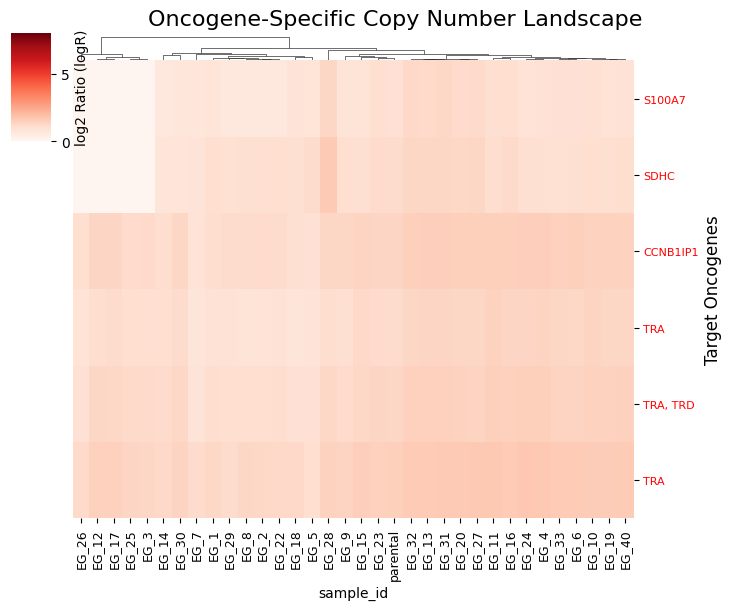

In [408]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. cgc_gene이 존재하는 데이터만 필터링 (가장 핵심!)
df_filtered = df_target.dropna(subset=['cgc_gene']).copy()

# 2. Bin ID 및 정렬 기준 생성
df_filtered['bin_id'] = "Chr" + df_filtered['chr'].astype(str) + ":" + df_filtered['start'].astype(str)
df_filtered['start_num'] = df_filtered['start'].astype(float)

# 유전체 순서대로 정렬된 Bin 리스트 (필터링된 데이터 기준)
sorted_bins = df_filtered[['chr', 'start_num', 'bin_id']].drop_duplicates() \
                .sort_values(['chr', 'start_num'])['bin_id'].tolist()

# 3. Pivot Table 생성
pivot_oncogene = df_filtered.pivot_table(index='bin_id', 
                                         columns='sample_id', 
                                         values='logR', 
                                         aggfunc='mean')

# 순서 고정 및 결측치 처리
pivot_oncogene = pivot_oncogene.reindex(index=sorted_bins).fillna(0)

# 4. Clustermap 시각화
# 데이터가 줄어들었으므로 figsize 세로 길이를 줄여도 됩니다 (예: 18 -> 12)
cg = sns.clustermap(pivot_oncogene, 
                    row_cluster=False,  # 유전체 순서 유지
                    col_cluster=True,   # 샘플 계통군 클러스터링
                    cmap="Reds", 
                    vmin=0, vmax=8, 
                    figsize=(8, 6),    
                    cbar_kws={'label': 'log2 Ratio (logR)'},
                    dendrogram_ratio=(0.1, 0.05)) # 트리 크기 조절

# 5. Y축 라벨에 유전자 이름 직접 넣기
# bin_id 대신 해당 구간의 유전자 이름을 라벨로 사용합니다.
bin_to_gene = df_filtered.set_index('bin_id')['cgc_gene'].to_dict()
new_yticklabels = [bin_to_gene.get(b, b) for b in sorted_bins]

cg.ax_heatmap.set_yticks(np.arange(len(new_yticklabels)) + 0.5)
cg.ax_heatmap.set_yticklabels(new_yticklabels, rotation=0, fontsize=8, color='red')
cg.ax_heatmap.set_ylabel("Target Oncogenes", fontsize=12)

# X축 샘플 이름 90도 회전 (기존 요청 반영)
plt.setp(cg.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9)

cg.fig.suptitle("Oncogene-Specific Copy Number Landscape", fontsize=16, y=1.02)
plt.show()